In [353]:
"""
LDA PIPELINE -- ALL-SESSIONS VARIANT
====================================
A copy of LDA_analyses_pipeline_CORRECTED with two changes, both about WHICH
sessions define things. Everything else is identical.

1. BALANCED SUBSAMPLING KEEPS EVERY MOUSE (cells with `balanced_idx`).
   The original rule was
       if len(m_idx) >= cap: rng.choice(m_idx, cap)
   which dropped a mouse with fewer sessions than the cap out of the TRAINING set
   while still TESTING it -- against a classifier that had never seen it, so those
   folds were guaranteed misses. Because the guard is evaluated after leave-one-out,
   a mouse fell below it precisely in the folds where it was the test item. With 20
   of 58 mice having exactly 3 sessions, n_per_mouse=4 turned 22% of folds into
   automatic errors and accuracy dropped for that reason alone. The cap is now a
   maximum contribution rather than a minimum requirement:
       take = min(cap, len(m_idx))
   Measured effect: n_per_mouse 3 / 4 / 5 gives 0.770 / 0.651 / 0.480 under the old
   rule and 0.770 / 0.814 / 0.848 under this one -- monotone, as expected.

   THE CAP IS NOW n_per_mouse ITSELF, not n_per_mouse - 1. The -1 only ever existed to
   guarantee that every mouse could meet the cap under the broken guard; `take = min(...)`
   makes it redundant, and it had left the scoring cell capping at 2 while the embedding
   cells capped at 3. Consequence: the score this notebook reports RISES (cap 2 -> 3 is
   roughly the 0.758 -> 0.849 step in the table above). That is a change of definition,
   not a bug fix, so any previously quoted number has to be re-quoted.

2. THE SAVED EMBEDDING IS FIT ON ALL SESSIONS (the `final_transformed` cell).
   It used to be fit on whatever X_train the loop above happened to leave behind --
   one arbitrary balanced draw from the last fold. That made the saved embedding
   irreproducible: two draws under the same rule give LD1 axes correlating anywhere
   from 0.05 to 0.85, because the leading LDA eigenvalues are near-degenerate
   (0.267 vs 0.253) and each draw picks a different rotation within the same
   subspace. Fitting on every session is deterministic (two refits give |rho| = 1.0).

   KNOWN LIMITATION of change 2: sessions per mouse are unequal (3 to 16), so mice
   with more sessions weigh more in the pooled within-class scatter, and mice with
   fewer get noisier -- therefore more extreme -- class means. Set EMBED_BALANCED to
   True to fit the embedding on one balanced draw per mouse instead (reproducible via
   EMBED_SEED, but back to depending on a draw).
"""
EMBED_BALANCED = False     # False = fit the embedding on all sessions
EMBED_SEED = 0             # only used when EMBED_BALANCED is True

# =============================================================================
# DATA FILTERING -- every "which data goes in" decision, in one place
# =============================================================================
# These four knobs are the only places that decide what the pipeline sees. They are
# applied in filter_sequences (sessions, mice) and build_design_matrix (trials), so
# changing them here changes every cell below at once.
#
# WHY THIS EXISTS. The syllable file is ~1% missing overall, but the loss is concentrated
# in a couple of animals: CSH_ZAD_026 loses 10-21% of its bins and NYU-30 32-54%. Traced
# back, both are RIGHT-PAW tracking dropouts -- 97% and 91% of their missing states are
# frames where r_paw_x/r_paw_y are NaN and every other signal is present. The paw HMM is
# fit on both paws, so a right-paw dropout costs the whole syllable even though whisking
# and licking were measured fine. NYU-30's three sessions are exactly the ones the QC
# sheet marks 'need to revise' ("right paw might be occluded?", video QC FAIL both sides).
#
# WHAT IT COSTS TO FILTER (measured, refit each time; LD1's sign is arbitrary):
#   nothing dropped                269 sessions  58 mice  LOO 0.848    --
#   DROP_INCOMPLETE_TRIALS=True    269 sessions  58 mice  LOO 0.838   |r| LD1 vs ref 0.994
#   MAX_SESSION_MISSING=0.05       259 sessions  56 mice  LOO 0.859   |r| 0.817
#   QC 'filtered_out_and_revise'   263 sessions  57 mice  LOO 0.852   |r| 0.909
# The axis is insensitive to the missing data itself (the trial-level test is the direct
# one: |r| = 0.994). The session/mouse filters move it more only because they remove
# whole ANIMALS, and the animals they remove are extreme -- dropping two equally extreme
# but well-tracked mice perturbs LD1 just as much (|r| 0.74-0.91). So filtering is about
# what you are willing to call behaviour, not about rescuing the axis.

QC_STRICTNESS = 'filtered_out'
# Which sessions the curated QC sheet removes (session_filters.exclusions_by_timepoint):
#   'filtered_out'            -> 'Used in paper' == 'filtered out'         (12 sessions)
#   'filtered_out_and_revise' -> those PLUS 'need to revise'               (21 sessions)
# The stricter setting is the principled way to lose NYU-30: it is a curated judgement
# rather than a threshold chosen after seeing the result.

MAX_SESSION_MISSING = None
# Drop sessions with more than this fraction of NaN bins. None = keep every session.
# Measured over the 269 sessions that reach the LDA -- note how fast this bites, because
# the 3-session minimum takes whole mice down with the sessions:
#   > 20%  ->  4 sessions,  1 mouse lost (NYU-30)                   ->  4 sessions gone
#   > 10%  ->  8 sessions,  2 mice lost (+ CSH_ZAD_026)             ->  9 sessions gone
#   >  5%  ->  9 sessions,  2 mice lost                             -> 10 sessions gone
#   >  2%  -> 19 sessions,  4 mice lost (+ NYU-48, ibl_witten_27)   -> 23 sessions gone
#   >  1%  -> 24 sessions,  5 mice lost (+ NYU-39)                  -> 27 sessions gone
#   > 0.5% -> 29 sessions,  7 mice lost                             -> 36 sessions gone
# The median session is at 0.00% and the 90th percentile at 0.7%, so anything below ~1%
# stops screening artifacts and starts screening ordinary sessions: at 1% you would lose
# 5 mice, 3 of which are not flagged by any QC criterion.

DROP_INCOMPLETE_TRIALS = False
# Trial-level screen: drop any trial with a missing bin anywhere in its four epochs,
# instead of letting the per-session mean skip the missing bins. This is the honest test
# of whether missing data biases the features, because it changes nothing else -- no mouse
# and no session leaves. It costs CSH_ZAD_026 ~75% of its trials and NYU-30 ~85% and still
# reproduces the axis at |r| = 0.994, which is why the missing data is not treated as a
# threat to LD1 anywhere below.

MIN_SESSIONS_PER_MOUSE = 3
# A mouse needs at least this many surviving sessions to stay a class. Was hardcoded as
# `session_count > 2` inside filter_sequences. It is applied AFTER the other screens, so
# raising MAX_SESSION_MISSING can remove a mouse without naming it -- filter_sequences
# now prints which mice go and why.

# =============================================================================
# LAB VARIANCE
# =============================================================================
# =============================================================================
# WHICH SYLLABLE CHANNELS GO INTO THE LDA
# =============================================================================
SYLLABLE_CHANNELS = ('paw', 'whisk', 'lick')      # any subset, e.g. ('paw',)
# SYLLABLE_CHANNELS = ('paw', 'whisk')      # any subset, e.g. ('paw',)
# SYLLABLE_CHANNELS = ('paw',)      # any subset, e.g. ('paw',)
# A syllable is (paw state, whisking on/off, licking on/off). binarize() lays each
# timestep out as 7 paw one-hot columns (paw state 1 is the dropped reference) + whisk +
# lick = 9, so a channel is a clean column subset and nothing else in the pipeline changes.
#
# WHY YOU MIGHT DROP CHANNELS. Measured on these 269 sessions -- lab share of variance from
# the nested partition, mouse identification leave-one-session-out, and lab decoded from a
# HELD-OUT MOUSE (chance 0.017 and 0.100):
#
#   channels             feat    lab    mouse   p        mouse ID   lab
#   paw + whisk + lick    360   0.166   0.490   <0.001     0.848    0.398
#   paw + whisk           320   0.114   0.526   <0.001     0.794    0.297
#   paw only              280   0.042   0.505    0.111     0.736    0.234
#   whisk only             40   0.208   0.554   <0.001     0.513    0.338
#   lick only              40   0.345   0.366   <0.001     0.435    0.375
#
# PAW ONLY IS THE ONLY SUBSET WITH NO DETECTABLE LAB EFFECT (p = 0.111) and it still
# identifies the mouse at 0.736 of 58. Lick costs 5 points of identification and buys back
# 10 points of lab leakage; it is also the channel the QC sheet flags separately
# (lick_detection, "bad lick fit"). The same ranking appears in the RAW video signals
# (Lick count 0.338 lab, whisker_me 0.166, paw velocities 0.030-0.167), so it is a property
# of the signals, not of the HMM discretisation.
#
# WHAT IT COSTS: the axis changes. This is a different feature space, so LD1 from a
# paw-only run is not the LD1 the rest of the paper quotes -- refit and re-check any
# correlate you carry over, and say which channels were used.

LAB_CORRECTION = None      # 'none' | 'center' | 'zscore'
# Applied to the session x feature matrix before PCA (the `all_features` cell), by
# functions.remove_lab_variance:
#   'center'  subtract each lab's mean feature vector
#   'zscore'  subtract the lab mean AND divide by the lab's SD across its sessions, so
#             per-lab scale goes too, not only per-lab level
# The lab mean is the mean of the lab's PER-MOUSE means, not of its sessions: session
# counts inside a lab run 3 to 16, and a session-weighted mean would be dominated by the
# busiest animal, so centring would subtract mostly that one mouse from its lab-mates.
# Labs are read offline from the QC sheet's rig_name (10 labs here, 3 to 9 mice each);
# no mouse spans two labs.
#
# READ THIS BEFORE TURNING IT ON. Lab is NESTED INSIDE MOUSE -- every mouse belongs to
# exactly one lab -- so this is not a nuisance regressor that leaves the signal intact.
# After centring, the corrected mouse means within a lab sum to zero, so mouse identity
# loses one dimension per lab: 10 of the 57 discriminant dimensions. The loss is uneven,
# because it is one dimension per lab regardless of size -- a 3-mouse lab gives up 1 of
# its 2 between-mouse dimensions, a 9-mouse lab 1 of 8. Expect the LDA score to fall, and
# expect it to fall further for mice in small labs; that drop is the correction working,
# not a bug, but it is also not separable from "lab differences ARE part of what makes
# these mice different" (rig, camera placement, handling, water schedule).
#
# So the honest use is a COMPARISON, not a replacement: run 'none' and 'center' and report
# both. What survives the correction is individuality that is not explained by lab; what
# does not survive is either lab nuisance or lab-linked individuality, and this design
# cannot tell those apart.

# ---- SHARED FIGURE STYLE ----------------------------------------------------
# paper-individuality/paper_style.py holds every cross-figure decision: which colour
# a timepoint is, what LD1's gradient looks like, panel sizes, where figures are
# written. Run this BEFORE the imports cell, which does an os.chdir.
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
sys.path.insert(0, str(_root))
sys.path.insert(0, str(_root / 'learning_individuality'))   # session_filters lives there
import importlib
import paper_style
importlib.reload(paper_style)   # kernels cache modules: without this, edits to
ps = paper_style                # paper_style stay invisible until a restart
ps.use('poster')      # 'poster' = big type for a poster; 'paper' = journal sizes

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


'poster'

# Individuality dimensions with LDA

In [354]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'

In [355]:
""" 
IMPORTS
"""
import os
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# --Machine learning and statistics

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler,  LabelBinarizer
import umap
from sklearn import mixture
import pickle
from scipy.stats import mode
from sklearn.metrics.pairwise import pairwise_distances
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA
from statsmodels.distributions.empirical_distribution import ECDF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy import stats
from sklearn.metrics import f1_score
from scipy.stats import zscore

# Get my functions. RELOAD, for the same reason paper_style and session_filters are
# reloaded above: a long-lived kernel caches modules, so edits to 4_mice/functions.py stay
# invisible until a restart. Without this you get a stale `functions` -- the symptom is an
# ImportError for a name that plainly exists in the file, or a TypeError about a keyword
# argument (return_ci) that the cached copy predates.
import importlib
import functions
importlib.reload(functions)
from functions import get_metadata
functions_path =  prefix + 'representation_learning_variability/Models/Sub-trial//3_postprocess_results/'
os.chdir(functions_path)
from plotting_functions import create_grouped_gradient_palette

from one.api import ONE
one = ONE(mode='remote')

In [356]:
""" IMPORTANT PATHS """
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/newly_generated/segmentation/'
base_path = '/Users/ineslaranjeira/Google Drive/O meu disco/CCU/PhD Project/paper-individuality/data/'
base_path = '/home/ines/repositories/representation_learning_variability/paper-individuality/data/'
# base_path = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/'

## Load sequence data

In [357]:
n_paw_states = 8

# Explicit filenames per data type -- add/remove/comment entries to control which data types
# are loaded and combined into the final design matrix (previously done by commenting/
# uncommenting a single `filename` variable below). Fill in the paths you want to use.
data_files = {
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    'raw': base_path + '10_bin_raw_16-06-2026',
    'trial': base_path + 'all_trials_04-05-2026',
}

data_files = {
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    'trial': base_path + 'session_trial_meta_10-07-2026',
}
data_files = {
    # 'syllables': base_path + '8_k_10_bin_syllables_06-07-2026',
    'syllables': base_path + '8_k_10_bin_syllables_17-06-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    # 'trial': base_path + 'session_trial_meta_10-07-2026',
}

data_files = {
    # 'syllables': base_path + '8_k_10_bin_syllables_06-07-2026',
    'syllables': base_path + '8_k_10_bin_syllables_19-08-2026',
    # 'syllables': base_path + 'paw_wheel_8_k_10_bin_syllables_28-08-2026',
    # 'raw': base_path + '10_bin_raw_16-06-2026',
    # 'trial': base_path + 'session_trial_meta_10-07-2026',
}


### Filter data

In [358]:
""" SESSION EXCLUSIONS -- from the curated QC sheet, not a hardcoded list.

Same logic as the learning_individuality scripts: session_filters reads
individuality-paper_data_4Sep26.csv (now under paper-individuality/data/, found
wherever it lives by session_filters.find_csv) and returns the eids whose
`Used in paper` column says to drop them. Changing the sheet changes every analysis
at once, and the two folders can no longer drift apart.

  QC_STRICTNESS 'filtered_out'            -> drop Used in paper == 'filtered out'
                'filtered_out_and_revise' -> drop those PLUS 'need to revise'

This pipeline only reads the proficient (recording) file, so it takes the Proficient
exclusions. The previous hardcoded list of 3 eids is still in
LDA_analyses_pipeline_CORRECTED.ipynb if you need to compare.
"""
# A long-lived kernel caches imported modules, so edits to session_filters -- or
# the QC sheet moving folders -- stay invisible until a restart. Reload explicitly.
import importlib, session_filters
importlib.reload(session_filters)
from session_filters import exclusions_by_timepoint, find_csv

# QC_STRICTNESS, MAX_SESSION_MISSING and MIN_SESSIONS_PER_MOUSE are set in the header
# cell (cell 0) so that every filtering decision lives in one place. The fallbacks keep
# this cell runnable on its own.
QC_STRICTNESS = globals().get('QC_STRICTNESS', 'filtered_out')
MAX_SESSION_MISSING = globals().get('MAX_SESSION_MISSING', None)
MIN_SESSIONS_PER_MOUSE = globals().get('MIN_SESSIONS_PER_MOUSE', 3)
_excl = exclusions_by_timepoint(QC_STRICTNESS)
prob_sessions = sorted(_excl['Proficient'])
print(f"QC sheet: {find_csv()}")
print(f"exclusions ({QC_STRICTNESS}): "
      + ", ".join(f"{k} {len(v)}" for k, v in _excl.items())
      + f"  ->  {len(prob_sessions)} proficient sessions dropped")  # Ago 7 2026

# f3eeb2d4-87ce-49ae-8a74-21665f6f1536



def filter_sequences(all_sequences):
    """Apply, in order: the QC sheet, the missing-data screen, the per-mouse session
    minimum. Every threshold comes from the header cell; nothing is hardcoded here."""
    print(f'{all_sequences.mouse_name.nunique()} mice, '
          f'{all_sequences.session.nunique()} sessions in total')

    # 1. curated QC sheet
    all_sequences = all_sequences.loc[~all_sequences['session'].isin(prob_sessions)].reset_index(drop=True)
    print(f'{all_sequences["session"].nunique()} sessions after the QC sheet ({QC_STRICTNESS})')

    # how many sessions each mouse had BEFORE the missing-data screen, so the report
    # below can separate "this mouse never had enough sessions" (43 of them do not, and
    # saying so every run is noise) from "the screen took this mouse out" (the only
    # interesting case -- and the one that is otherwise invisible, since a mouse that
    # loses every session disappears from the counts entirely)
    _before = (all_sequences[['mouse_name', 'session']].drop_duplicates()
               .groupby('mouse_name')['session'].count())

    # 2. missing-data screen. Only for sequence files -- a trial-metadata file has no
    # binned_sequence column and nothing to screen.
    if MAX_SESSION_MISSING is not None and 'binned_sequence' in all_sequences.columns:
        _nan = np.isnan(np.stack(all_sequences['binned_sequence'].to_numpy())).mean(axis=1)
        _frac = pd.Series(_nan, index=all_sequences['session'].to_numpy()).groupby(level=0).mean()
        _drop = _frac[_frac > MAX_SESSION_MISSING]
        all_sequences = all_sequences.loc[~all_sequences['session'].isin(_drop.index)].reset_index(drop=True)
        print(f'{all_sequences["session"].nunique()} sessions after dropping '
              f'{len(_drop)} with > {MAX_SESSION_MISSING:.1%} missing bins '
              f'(worst {_drop.max():.1%})' if len(_drop) else
              f'{all_sequences["session"].nunique()} sessions -- none exceed '
              f'{MAX_SESSION_MISSING:.1%} missing bins')

    # 3. per-mouse session minimum, applied LAST so it sees what the screens left
    session_count = (all_sequences[['mouse_name', 'session']].drop_duplicates()
                     .groupby(['mouse_name'])['session'].count())
    multi_sess_mice = session_count[session_count >= MIN_SESSIONS_PER_MOUSE].index
    all_sequences = all_sequences.loc[all_sequences['mouse_name'].isin(multi_sess_mice)].reset_index(drop=True)
    print(f'{len(multi_sess_mice)} mice with at least {MIN_SESSIONS_PER_MOUSE} sessions, '
          f'{all_sequences["session"].nunique()} remaining sessions')

    _after = session_count.reindex(_before.index).fillna(0).astype(int)
    _short = _before[_before < MIN_SESSIONS_PER_MOUSE]
    _taken = _before[(_before >= MIN_SESSIONS_PER_MOUSE) & (_after < MIN_SESSIONS_PER_MOUSE)]
    if len(_short):
        print(f'  {len(_short)} mice never had {MIN_SESSIONS_PER_MOUSE} sessions to begin with')
    if len(_taken):
        print('  mice DROPPED BY THE MISSING-DATA SCREEN (had enough sessions, no longer do): '
              + ', '.join(f'{m} {_before[m]}->{_after[m]}' for m in _taken.index))

    assert 'index' not in all_sequences.columns, "ERROR: 'index' column created by reset_index!"
    assert len(all_sequences) > 0, 'ERROR: every session was filtered out'
    print("✓ Data preparation validated")
    return all_sequences


QC sheet: /home/ines/repositories/representation_learning_variability/paper-individuality/data/individuality-paper_data_4Sep26.csv
exclusions (filtered_out): Early 15, Late 9, Pre-rec 76, Proficient 12  ->  12 proficient sessions dropped


# Encode syllables for LDA

In [359]:
def binarize(n_features_per_step, use_sequences, n_paw_states=8):
    """
    Binarizes behavioral sequence data dynamically based on the number of paw states.
    
    Parameters:
    -----------
    n_features_per_step : int
        Total features per step *before* dropping the reference column (e.g., 10).
    use_sequences : np.ndarray
        Array of shape (n_trials, timesteps) containing encoded integer states or NaNs.
    n_paw_states : int
        The number of possible paw states (defaults to 8).
    """
    n_trials = use_sequences.shape[0]
    timesteps = use_sequences.shape[1]

    binarized = np.zeros((n_trials, timesteps * n_features_per_step))
    
    for t in range(timesteps):
        current_vals = use_sequences[:, t]
        nan_mask = np.isnan(current_vals)
        valid_mask = ~nan_mask
        labels_0idx = current_vals[valid_mask].astype(int)
        start_col = t * n_features_per_step
        
        if len(labels_0idx) > 0:  
            valid_row_idx = np.arange(n_trials)[valid_mask]
            
            # 1. Fill Paw States (Cols 0 to n_paw_states-1)
            paw_indices = labels_0idx % n_paw_states
            binarized[valid_row_idx, start_col + paw_indices] = 1
            
            # 2. Fill Whisking (Col equal to n_paw_states)
            whisking_col = start_col + n_paw_states
            binarized[valid_mask, whisking_col] = ((labels_0idx // n_paw_states) % 2).astype(int)
            
            # 3. Fill Licking (Col equal to n_paw_states + 1)
            licking_col = start_col + n_paw_states + 1
            binarized[valid_mask, licking_col] = (labels_0idx // (n_paw_states * 2)).astype(int)
        
        # Set all features for this timestep to NaN where original data was NaN
        if np.any(nan_mask):
            feature_cols = slice(start_col, start_col + n_features_per_step)
            binarized[nan_mask, feature_cols] = np.nan

    # Dynamically eliminate Paw State 2 (index 1) for every timestep
    # Using 'n_features_per_step' ensures this steps accurately across the array
    cols_to_delete = [t * n_features_per_step + 1 for t in range(timesteps)]
    binarized_reduced = np.delete(binarized, cols_to_delete, axis=1)
    
    return binarized_reduced

In [360]:
def build_design_matrix(filename, n_paw_states=8):
    """Load one data-type file (syllables / raw / trial, detected from the filename -- same
    branch logic as before, just parameterized instead of hardcoded to a single `filename`)
    and return its per-session-averaged (session_syllables, design_df)."""
    all_sequences = pd.read_parquet(filename)

    if 'syllables' in filename or 'sequences' in filename or 'raw' in filename:
        all_sequences['session'] = all_sequences['sample'].str[:36]

    all_sequences = filter_sequences(all_sequences)

    if 'syllables' in filename or 'sequences' in filename:     
        design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values='binned_sequence').reset_index().dropna()
        # Remove any spurious 'index' column created by reset_index
        if 'index' in design_df.columns:
            design_df = design_df.drop(columns=['index'])
        design_df = design_df.sort_values(by='session')

        # Validate
        assert len(design_df) > 0, "ERROR: design_df is empty after filtering!"
        print(f"✓ design_df created: {len(design_df)} rows, {design_df['mouse_name'].nunique()} mice, {design_df['session'].nunique()} sessions")

        epoch_to_analyse = ['Pre-quiescence', 'Quiescence', 'Choice', 'ITI']
        use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

        # Validate alignment
        assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length ({len(use_sequences)}) != design_df length ({len(design_df)})"

        # Trial-level missing-data screen (header cell). Without it a trial with missing
        # bins still contributes: binarize marks those features NaN and the per-session
        # mean skips them, so the timestep is averaged over a non-random subset of trials.
        # With it, only trials complete in all four epochs count.
        if globals().get('DROP_INCOMPLETE_TRIALS', False):
            _keep = ~np.isnan(use_sequences).any(axis=1)
            print(f'  trial screen: {int(_keep.sum())}/{len(_keep)} trials complete '
                  f'({1 - _keep.mean():.1%} dropped)')
            use_sequences, design_df = use_sequences[_keep], design_df[_keep]
            assert design_df['session'].nunique() > 0, 'ERROR: no trials survive the screen'

        # --- PARAMETERS ---
        n_features_per_step = n_paw_states + 2  # X Paw + 1 Whisk + 1 Lick
        use_format  = binarize(n_features_per_step, use_sequences, n_paw_states)

        # Channel subsetting (header cell). AFTER binarize, each timestep is
        #   [paw 0, paw 2..paw 7]  (n_paw_states - 1 columns; paw state 1 is the reference)
        #   [whisk]  [lick]
        # so a channel is a column mask. Done here rather than downstream so that PCA, the
        # scaler, the LDA and every figure all see the same reduced matrix.
        _chan = tuple(globals().get('SYLLABLE_CHANNELS', ('paw', 'whisk', 'lick')))
        assert set(_chan) <= {'paw', 'whisk', 'lick'} and _chan, f'bad SYLLABLE_CHANNELS {_chan}'
        if set(_chan) != {'paw', 'whisk', 'lick'}:
            _n_paw_cols = n_paw_states - 1
            _per_step = _n_paw_cols + 2
            _within = np.arange(use_format.shape[1]) % _per_step
            _keep = np.zeros(use_format.shape[1], dtype=bool)
            if 'paw' in _chan:
                _keep |= _within < _n_paw_cols
            if 'whisk' in _chan:
                _keep |= _within == _n_paw_cols
            if 'lick' in _chan:
                _keep |= _within == _n_paw_cols + 1
            use_format = use_format[:, _keep]
            print(f"  channels {_chan}: {int(_keep.sum())} of {len(_keep)} features kept")

    elif 'raw' in filename:
        all_sequences['session'] = all_sequences['sample'].str[:36]
        binned_vars = ['Lick count_binned_sequence', 'whisker_me_binned_sequence', 
                       'l_paw_x_vel_binned_sequence', 'l_paw_y_vel_binned_sequence', 
                       'r_paw_x_vel_binned_sequence', 'r_paw_y_vel_binned_sequence']
        design_df = all_sequences.pivot(index=['mouse_name', 'session', 'sample', 'trial_type'], columns=['broader_label'], values=binned_vars).reset_index().dropna()
        if 'index' in design_df.columns:
            design_df = design_df.drop(columns=['index'])
        design_df = design_df.sort_values(by='session')
        # var_names = design_df.keys()[-4:]
        epoch_to_analyse = design_df.keys()[4:]
        use_sequences = np.vstack(design_df[epoch_to_analyse].apply(lambda row: np.hstack(row), axis=1))  # Transpose to get the right shape

        assert len(use_sequences) == len(design_df), f"ERROR: use_sequences length != design_df length"

        # Normalize
        use_format = zscore(use_sequences, axis=0, nan_policy='omit')

    elif 'trial' in filename:
        design_df = all_sequences.dropna()
        design_df['choice'] = design_df['choice'].map({'left': 0, 'right': 1}).astype(float)
        design_df['feedback'] = design_df['feedback'].map({'incorrect': 0, 'correct': 1}).astype(float)
        bias_df = (design_df[design_df['contrast'] == 0]
                .groupby(['session', 'block'])['choice'].mean()
                .unstack(level='block'))
        bias_df['bias'] = bias_df[0.8] - bias_df[0.2]
        merged = (design_df.groupby(['session', 'mouse_name'])
                .agg({'trial_id': 'count', 'reaction': 'median', 
                      'elongation': 'median', 'feedback': 'mean', 
                      'choice': 'mean', 'p_state1':'mean'
                      })
                .merge(bias_df['bias'], on='session', how='left'))

        merged['log_reaction'], merged['log_elongation'] = np.log(merged['reaction']), np.log(merged['elongation'])
        features = ['trial_id', 'feedback', 'choice', 'p_state1',
                    'log_reaction', 'log_elongation', 'bias']
        # use_format = merged[features].to_numpy()
        # use_format = zscore(use_format, axis=0, nan_policy='omit')
        clean_df = merged[features].dropna()
        use_format = clean_df.to_numpy()
        use_format = zscore(use_format, axis=0)

        design_df = clean_df.reset_index().merge(design_df[['mouse_name', 'session']], on='session').drop_duplicates()

    # Average per session (per data type)
    session_mouse_mapping = design_df[['session', 'mouse_name']].drop_duplicates()
    session_mouse_mapping = session_mouse_mapping.set_index('session')['mouse_name'].to_dict()

    # Validate: each session maps to exactly one mouse
    assert len(session_mouse_mapping) == len(design_df[['session', 'mouse_name']].drop_duplicates()), \
        "ERROR: A session maps to multiple mice!"

    session_syllables = pd.DataFrame(use_format)
    session_syllables['session'] = design_df['session'].values
    session_syllables = session_syllables.groupby('session', sort=False)[np.arange(0, np.shape(use_format)[1], 1)].mean()

    # Create mouse name labels using explicit mapping
    mouse_names_list = np.array([session_mouse_mapping[sess] for sess in session_syllables.index])

    print(f"✓ Session aggregation complete: {len(session_syllables)} sessions")
    print(f"✓ Mouse labels: {dict(zip(*np.unique(mouse_names_list, return_counts=True)))}")

    return session_syllables, design_df


## Average per session

In [361]:
results = {}
for data_type, filename in data_files.items():
    print(f'--- {data_type}: {filename} ---')
    session_syllables_i, design_df_i = build_design_matrix(filename, n_paw_states=n_paw_states)
    # Prefix columns with the data type so integer column names from different types
    # (0, 1, 2, ...) don't collide when appended together below.
    results[data_type] = {
        'session_syllables': session_syllables_i.add_prefix(f'{data_type}_'),
        'design_df': design_df_i,
    }

# Append (column-wise) into one combined design matrix -- inner join keeps only sessions
# present in every loaded data type.
session_syllables = pd.concat([r['session_syllables'] for r in results.values()], axis=1, join='inner')
design_df = pd.concat([r['design_df'][['mouse_name', 'session']] for r in results.values()],
                       ignore_index=True).drop_duplicates()

print(f"✓ Combined design matrix: {len(session_syllables)} sessions, {session_syllables.shape[1]} features "
      f"(data types: {list(data_files.keys())})")


--- syllables: /home/ines/repositories/representation_learning_variability/paper-individuality/data/8_k_10_bin_syllables_19-08-2026 ---
101 mice, 332 sessions in total
330 sessions after the QC sheet (filtered_out)
58 mice with at least 3 sessions, 269 remaining sessions
  43 mice never had 3 sessions to begin with
✓ Data preparation validated
✓ design_df created: 166617 rows, 58 mice, 269 sessions
✓ Session aggregation complete: 269 sessions
✓ Mouse labels: {np.str_('CSHL045'): np.int64(5), np.str_('CSHL049'): np.int64(4), np.str_('CSHL052'): np.int64(4), np.str_('CSHL053'): np.int64(4), np.str_('CSHL058'): np.int64(3), np.str_('CSHL059'): np.int64(5), np.str_('CSHL060'): np.int64(5), np.str_('CSH_ZAD_019'): np.int64(3), np.str_('CSH_ZAD_026'): np.int64(6), np.str_('CSH_ZAD_029'): np.int64(6), np.str_('DY_009'): np.int64(9), np.str_('DY_010'): np.int64(4), np.str_('DY_011'): np.int64(4), np.str_('DY_014'): np.int64(6), np.str_('DY_016'): np.int64(5), np.str_('DY_018'): np.int64(3), np

Text(0, 0.5, 'Sessions')

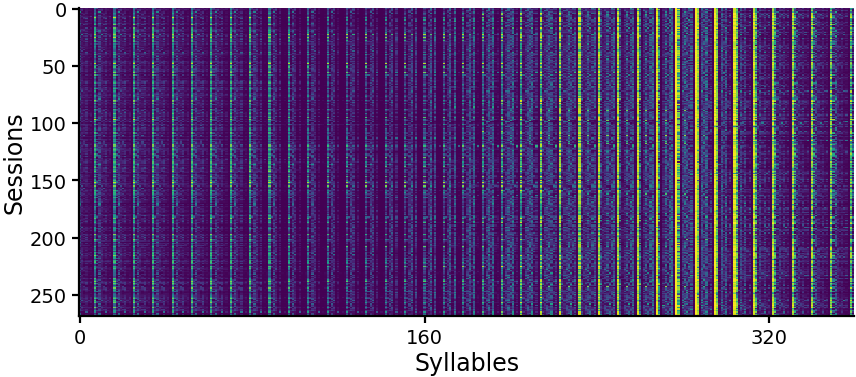

In [362]:
plt.figure(figsize=(10, 4))
plt.imshow(np.array(session_syllables), aspect='auto', cmap='viridis', interpolation='none')
plt.xticks(np.arange(0, session_syllables.shape[1], 160), np.arange(0, session_syllables.shape[1], 160))
plt.xlabel('Syllables')
plt.ylabel('Sessions')

# Dimensionality reduction

In [363]:
all_features = session_syllables.copy()

# ---- LAB VARIANCE (knob in the header cell) ---------------------------------------
# Done HERE, on the raw session x feature matrix, so everything downstream -- PCA, the
# scaler, the LDA, every figure -- sees the corrected features. Labs come from the QC
# sheet's rig_name, so no ONE call is needed.
import importlib
import functions
importlib.reload(functions)
from functions import lab_labels, lab_variance_explained, remove_lab_variance

_mouse_of_session = pd.Series(
    all_features.index.map(design_df[['mouse_name', 'session']].drop_duplicates()
                           .set_index('session')['mouse_name']),
    index=all_features.index)
lab_of_session = lab_labels(all_features.index, mouse_names=_mouse_of_session)
_n_by_lab = _mouse_of_session.groupby(lab_of_session).nunique()
print('mice per lab:', ', '.join(f'{k} {v}' for k, v in _n_by_lab.sort_values().items()))
print(f"lab share of feature variance (mean eta^2): "
      f"{lab_variance_explained(all_features, lab_of_session):.3f}"
      "   -- how much of the variance a lab label alone accounts for; it does NOT say the "
      "cause is the lab rather than the mice in it")

if LAB_CORRECTION != 'none':
    all_features = remove_lab_variance(all_features, lab_of_session,
                                       mode=LAB_CORRECTION, mouse_names=_mouse_of_session)
    print(f"  after {LAB_CORRECTION!r}: "
          f"{lab_variance_explained(all_features, lab_of_session):.3f}")


  1 session(s) had no rig in the sheet; lab taken from the mouse
  labs: 10 for 269 sessions
mice per lab: zadorlab 3, wittenlab 3, steinmetzlab 4, churchlandlab_ucla 5, hausserlab 6, danlab 7, mainenlab 7, churchlandlab 7, mrsicflogel 7, angelakilab 9
lab share of feature variance (mean eta^2): 0.181   -- how much of the variance a lab label alone accounts for; it does NOT say the cause is the lab rather than the mice in it
  after None: 0.181


25 components explain 0.95 of total variance


Text(0.5, 1.0, 'Explained Variance by PCA')

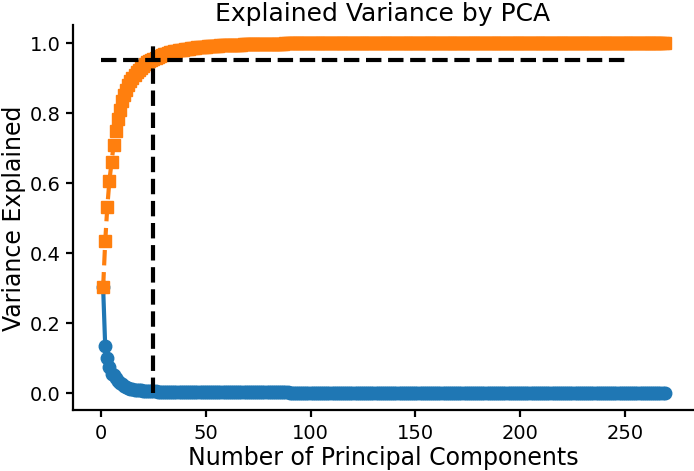

In [364]:
# PCA
n_components = np.min([np.shape(np.array(all_features))[0], np.shape(np.array(all_features))[1]])
# Step 1: Reduce dimensions with PCA
pca = PCA(n_components)  # Reduce to 50 dimensions
scaler = StandardScaler()
# standardized_X = scaler.fit_transform(np.array(all_features))
# X_pca = pca.fit_transform(standardized_X)
X_pca = pca.fit_transform(np.array(all_features))

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
threshold = 0.95
min_components = np.where(cumulative_variance>threshold)[0][0]
min_components = 25
print(str(min_components) + ' components explain ' + str(threshold) +' of total variance')

# Plot explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components+1), explained_variance_ratio, marker='o', label='Individual')
plt.plot(range(1, n_components+1), cumulative_variance, marker='s', label='Cumulative', linestyle='--')
plt.hlines(threshold, 0, 250, 'black', 'dashed')
plt.vlines(min_components, 0, 1, 'black', 'dashed')
plt.xlabel("Number of Principal Components")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by PCA")

In [365]:
# min_components = 10

In [366]:
mat = np.array(session_syllables.copy())
mat = np.array(X_pca[:, :min_components])

scaler = StandardScaler()
norm_pop = scaler.fit_transform(mat.copy())

# LDA

In [367]:
mapping = pd.DataFrame(np.array(design_df[['mouse_name', 'session']].drop_duplicates()), columns=['mouse_name', 'session'])
df_with_sessions = session_syllables.reset_index()
mouse_names = df_with_sessions.merge(mapping, on=['session'])['mouse_name']
df = df_with_sessions.merge(mapping, on=['session'])

In [368]:
n_per_mouse = 3
lda_components = 30
lda_components = np.min([min_components, len(mouse_names.unique())-1])
# lda_components = 30
n_repeats = 10

final_matrix = np.array(norm_pop)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]
n_samples = X.shape[0]
rng = np.random.default_rng(0)

# Store repeat results
true_scores_all = []
shuffle_scores_all = []

for repeat in range(n_repeats):
    scores_true = []
    scores_shuff = []

    # Subsample balanced sessions for training in each fold
    for test_idx in range(n_samples):
        X_test = X[test_idx:test_idx+1]
        y_test = y[test_idx:test_idx+1]
        train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
        X_train_full = X[train_idx]
        y_train_full = y[train_idx]

        # --- balanced subsampling for training ---
        # the cap is a MAXIMUM contribution, not a minimum requirement -- see the
        # header cell. Every mouse stays a class, sparse ones contribute what they have.
        balanced_idx = []
        for m in np.unique(y_train_full):
            m_idx = np.where(y_train_full == m)[0]
            # cap = n_per_mouse exactly. The old `n_per_mouse - 1` dated from the
            # BROKEN guard, where cap 2 was the largest value every mouse could always
            # meet (filter_sequences keeps >= 3 sessions, leave-one-out removes at most
            # one), so nobody was ever dropped. `take = min(...)` handles short mice
            # directly, so the -1 is redundant -- and it made this cell disagree with
            # the embedding cells below, which already cap at n_per_mouse.
            take = min(n_per_mouse, len(m_idx))
            if take > 0:
                balanced_idx.extend(rng.choice(m_idx, take, replace=False))
        balanced_idx = np.array(balanced_idx)
        assert y_test[0] in y_train_full[balanced_idx], (
            "the held-out mouse is not a training class -- this fold is unanswerable")
        X_train = X_train_full[balanced_idx]
        y_train = y_train_full[balanced_idx]

        # --- true labels run ---
        lda = LinearDiscriminantAnalysis(
            priors=np.ones(len(np.unique(y_train))) / len(np.unique(y_train)),
            n_components=lda_components)
        lda.fit(X_train, y_train)
        scores_true.append(lda.score(X_test, y_test))

        # --- shuffled labels run ---
        y_train_shuff = y_train.copy()
        rng.shuffle(y_train_shuff)
        lda_shuff = LinearDiscriminantAnalysis(
            priors=np.ones(len(np.unique(y_train_shuff))) / len(np.unique(y_train_shuff)),
            n_components=lda_components)
        lda_shuff.fit(X_train, y_train_shuff)
        scores_shuff.append(lda_shuff.score(X_test, y_test))
        
    # store average score for this repeat
    true_scores_all.append(np.mean(scores_true))
    shuffle_scores_all.append(np.mean(scores_shuff))

print("True labels mean ± std:", np.mean(true_scores_all), np.std(true_scores_all))
print("Shuffled labels mean ± std:", np.mean(shuffle_scores_all), np.std(shuffle_scores_all))

True labels mean ± std: 0.8368029739776951 0.009173949947400065
Shuffled labels mean ± std: 0.02007434944237918 0.006481634116789105


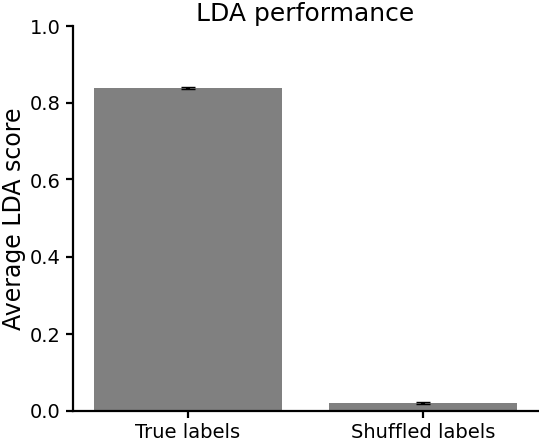

In [369]:
# Convert to arrays for convenience
true_scores = np.array(true_scores_all)
shuffle_scores = np.array(shuffle_scores_all)

# Compute means and standard deviations
means = [np.mean(true_scores), np.mean(shuffle_scores)]
stds  = [np.std(true_scores), np.std(shuffle_scores)]
std_errs = [np.std(true_scores)/np.sqrt(len(true_scores)), 
            np.std(shuffle_scores)/np.sqrt(len(shuffle_scores))]

labels = ['True labels', 'Shuffled labels']

# Create bar plot with error bars
plt.figure(figsize=(6,5))
plt.bar(labels, means, yerr=std_errs, color='grey', capsize=5) #, color=['skyblue','lightcoral']
plt.ylabel('Average LDA score')
plt.title('LDA performance')
plt.ylim(0,1)
# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'lda_score.svg', format='svg', bbox_inches='tight')
plt.show()

### How many LDA dimensions carry the mouse identity?

The sweep in `../segmentation/6_lda_score_sweep.py` varies how many **PCA** components go
*into* the LDA. This varies how many **discriminant axes** come *out* of it, with the input
fixed -- which is the question the paper actually leans on, because LD1 is read as a single
interpretable individuality axis. If identity were concentrated on LD1 the curve would
saturate immediately; if it is spread over many axes, LD1 is one slice of a broader
structure and should be described that way.

`LinearDiscriminantAnalysis(n_components=k)` cannot answer this -- `n_components` only
affects `transform`, never `predict`/`score`. So the classification is done explicitly as
nearest class mean in the first k discriminant dimensions, which with equal priors is
exactly sklearn's rule; at full rank it reproduces `lda.score` to the digit.


In [370]:
"""
LDA SCORE vs NUMBER OF LDA DIMENSIONS
"""
# reload first: this cell uses the newest additions to functions.py, so a kernel that
# imported the module earlier in the session would otherwise unpack the old 3-value return
import importlib
import functions
importlib.reload(functions)
from functions import lda_dimension_sweep

dims, dim_scores, dim_std, dim_lo, dim_hi = lda_dimension_sweep(
    design_df, session_syllables, min_components, norm_pop,
    n_per_mouse=n_per_mouse, n_repeats=n_repeats, return_ci=True, verbose=True)

n_mice = len(np.unique(pd.factorize(mouse_names)[0]))
_frac = dim_scores / dim_scores[-1]
for _f in (0.5, 0.8, 0.95):
    print(f'  {_f:.0%} of the full-rank score reached at {dims[np.argmax(_frac >= _f)]} LDA dims')
print(f'  full rank: {dim_scores[-1]:.3f}  [95% CI over mice {dim_lo[-1]:.3f}, '
      f'{dim_hi[-1]:.3f}]  (subsample spread +/-{dim_std[-1]:.3f})')


  repeat 1/10: max 0.840 at 25 LDA dims
  repeat 2/10: max 0.859 at 20 LDA dims
  repeat 3/10: max 0.855 at 23 LDA dims
  repeat 4/10: max 0.840 at 23 LDA dims
  repeat 5/10: max 0.862 at 19 LDA dims
  repeat 6/10: max 0.840 at 25 LDA dims
  repeat 7/10: max 0.848 at 19 LDA dims
  repeat 8/10: max 0.859 at 23 LDA dims
  repeat 9/10: max 0.840 at 25 LDA dims
  repeat 10/10: max 0.851 at 25 LDA dims
  50% of the full-rank score reached at 4 LDA dims
  80% of the full-rank score reached at 8 LDA dims
  95% of the full-rank score reached at 15 LDA dims
  full rank: 0.846  [95% CI over mice 0.801, 0.886]  (subsample spread +/-0.005)


wrote figures/lda_score_vs_lda_dimensions_poster_18-09-2026.png, figures/lda_score_vs_lda_dimensions_poster_18-09-2026.svg


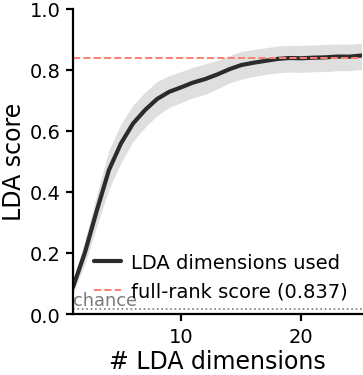

In [371]:
fig, ax = ps.figure('square', scale=.6)

ax.plot(dims, dim_scores, color=ps.STATE_INK, label='LDA dimensions used')
# Band = 95% CI from resampling MICE. NOT dim_std, which is the spread across training
# subsamples: it measures sensitivity to the random draw rather than uncertainty in the
# score, and it shrinks as n_per_mouse rises simply because a mouse with exactly
# n_per_mouse sessions has no choice left to make. See functions.bootstrap_over_mice.
ax.fill_between(dims, dim_lo, dim_hi, color=ps.STATE_INK, alpha=0.15, lw=0)

# The number from the scoring cell above. run_lda and lda_dimension_sweep now draw their
# balanced subsamples from the same stream, so the curve lands on this line EXACTLY rather
# than within draw noise -- no band needed on it any more.
_known = np.mean(true_scores)
ax.axhline(_known, color=ps.SYLLABLE['Paw 3'], ls='--', lw=1.4,
           label=f'full-rank score ({_known:.3f})')

ax.axhline(1 / n_mice, color=ps.NEUTRAL, ls=':', lw=1.2)
ax.text(dims[0], 1 / n_mice, f'chance ', ha='left', va='bottom',
        color=ps.NEUTRAL, fontsize=plt.rcParams['font.size'] * 0.8)

ax.set_xlabel('# LDA dimensions')
ax.set_ylabel(f'Mouse discriminability score\n(n_per_mouse = {n_per_mouse})')
ax.set_ylabel(f'LDA score')
ax.set_ylim(0, 1)
ax.set_xlim(dims[0], dims[-1])
# ax.set_title('25 PCA dimensions')
ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
ps.savefig(fig, 'lda_score_vs_lda_dimensions', svg=True)
plt.show()

### Rerun for analyses

In [372]:
n_per_mouse = 3
lda_components = 30
lda_components = min_components

# final_matrix = np.array(norm_array)
final_matrix = np.array(norm_pop)
# final_matrix = np.array(mat)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]
n_samples = X.shape[0]
rng = np.random.default_rng(0)

# Subsample balanced sessions for training in each fold
for test_idx in range(n_samples):

    X_test = X[test_idx:test_idx+1]
    y_test = y[test_idx:test_idx+1]

    train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
    X_train_full = X[train_idx]
    y_train_full = y[train_idx]

    # THIS CELL TRAINS ON ALL SESSIONS, NOT A BALANCED SUBSAMPLE.
    # A balanced draw used to be computed here and then thrown away two lines later by
    # an unconditional `X_train = X_train_full`, so it read as live but never affected
    # anything. Removed rather than left to mislead -- and removing it also stops the
    # dead rng.choice calls from advancing the generator.
    X_train = X_train_full
    y_train = y_train_full

# Fit for visualization

In [373]:
final_matrix = np.array(norm_pop)

In [374]:
# --- fit the SAVED embedding ---
# On ALL sessions, not on whatever X_train the loop above left behind. See the header
# cell: that leftover was one arbitrary balanced draw, and because the leading LDA
# eigenvalues are near-tied, different draws rotate LD1/LD2/LD3 among themselves --
# so the saved axis was not reproducible. Fitting on everything is deterministic.
X = final_matrix.copy()
y_embed = pd.factorize(mouse_names)[0]

if EMBED_BALANCED:
    _rng = np.random.default_rng(EMBED_SEED)
    _idx = []
    for m in np.unique(y_embed):
        m_idx = np.where(y_embed == m)[0]
        _idx.extend(_rng.choice(m_idx, min(n_per_mouse - 1, len(m_idx)), replace=False))
    _idx = np.sort(np.array(_idx))
    X_fit, y_fit = X[_idx], y_embed[_idx]
    print(f"embedding fit on ONE balanced draw: {len(_idx)} sessions "
          f"(seed {EMBED_SEED}) -- reproducible, but draw-dependent")
else:
    X_fit, y_fit = X, y_embed
    print(f"embedding fit on ALL {len(X)} sessions, "
          f"{len(np.unique(y_embed))} mice -- deterministic")

_ncls = len(np.unique(y_fit))
lda = LinearDiscriminantAnalysis(priors=np.ones(_ncls) / _ncls,
                                 n_components=min(lda_components, _ncls - 1))
lda.fit(X_fit, y_fit)
final_transformed = lda.transform(X)
print("LDA explained_variance_ratio_ (top 6):",
      np.round(lda.explained_variance_ratio_[:6], 3),
      "\n  near-equal leading values mean those axes are free to rotate among "
      "themselves; treat them as a subspace, not as individual axes")
clustered = pd.DataFrame(final_transformed)
clustered['mouse_name'] = mouse_names
clustered['mouse_number'] = pd.factorize(clustered['mouse_name'])[0]
# lab travels with the embedding whether or not LAB_CORRECTION was applied, so any
# downstream figure can colour or group by it (and so a 'none' run can be compared with
# a corrected one on the same axis)
if 'lab_of_session' in globals():
    clustered['lab'] = list(lab_of_session)
    clustered['lab_number'] = pd.factorize(clustered['lab'])[0]
# clustered['litter_id'] = litter_id
# clustered['litter_number'] = pd.factorize(clustered['litter_id'])[0]
clustered['session'] = session_syllables.reset_index()['session']

# clustered = clustered.merge(cluster_df[['mouse_name', 'mouse_cluster']].drop_duplicates(), on=['mouse_name'])

embedding fit on ALL 269 sessions, 58 mice -- deterministic
LDA explained_variance_ratio_ (top 6): [0.164 0.129 0.092 0.09  0.074 0.068] 
  near-equal leading values mean those axes are free to rotate among themselves; treat them as a subspace, not as individual axes


In [375]:
len(clustered.mouse_name.unique())

58

### Structural coefficients

In [384]:
component_to_plot = 2

channels ('paw', 'whisk', 'lick'): 40 timesteps x 9 features


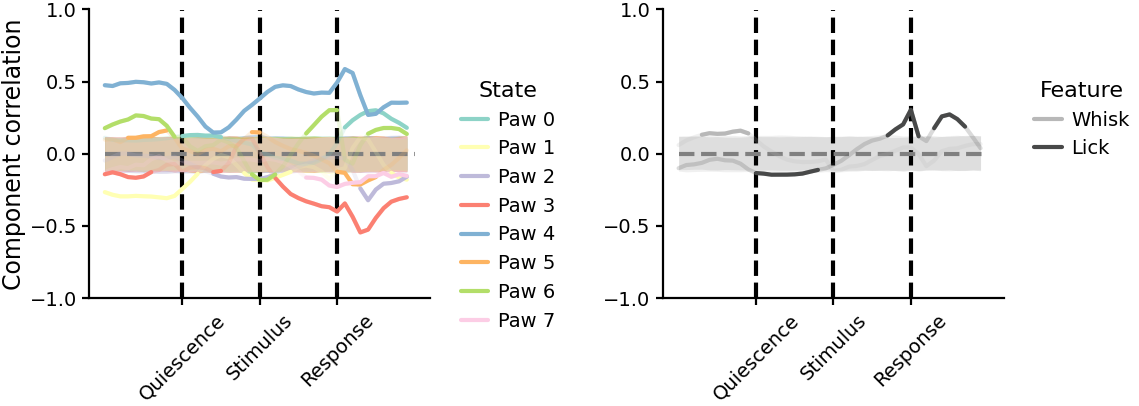

In [385]:
# 1. Get the LDA scores for all trials (their position on the LD1 axis)
lda_scores = final_transformed
y_true = lda_scores[:, component_to_plot]

feats = np.array(session_syllables)

# THE LAYOUT IS DERIVED, NOT ASSUMED. This cell used to hardcode 40 timesteps x 9 features
# per timestep; with SYLLABLE_CHANNELS set to anything but the full set the matrix is
# narrower (paw only -> 7 per timestep, 280 columns) and the reshape below fails. Read the
# channel list instead and check the arithmetic closes.
_chan = tuple(globals().get('SYLLABLE_CHANNELS', ('paw', 'whisk', 'lick')))
HAS_PAW, HAS_WHISK, HAS_LICK = ('paw' in _chan), ('whisk' in _chan), ('lick' in _chan)
n_paw_cols = (n_paw_states - 1) if HAS_PAW else 0
n_features_per_step = n_paw_cols + int(HAS_WHISK) + int(HAS_LICK)
timesteps = feats.shape[1] // n_features_per_step
assert timesteps * n_features_per_step == feats.shape[1], (
    f'{feats.shape[1]} features do not divide into {n_features_per_step} per timestep '
    f'for channels {_chan}')
print(f'channels {_chan}: {timesteps} timesteps x {n_features_per_step} features')

def colwise_pearsonr(X, y):
    """Vectorized per-column Pearson r between each column of X and y."""
    Xc = X - X.mean(axis=0, keepdims=True)
    yc = y - y.mean()
    num = Xc.T @ yc
    denom = np.sqrt((Xc**2).sum(axis=0)) * np.sqrt((yc**2).sum())
    return num / denom

# 2. Correlate each original syllable (360 features) with the true LDA scores
struct_coeffs = colwise_pearsonr(feats, y_true)
reshaped_struct = struct_coeffs.reshape(timesteps, n_features_per_step)

paw_importance = reshaped_struct[:, :n_paw_cols] if HAS_PAW else None
whisk_importance = reshaped_struct[:, n_paw_cols] if HAS_WHISK else None
lick_importance = reshaped_struct[:, n_paw_cols + int(HAS_WHISK)] if HAS_LICK else None

# Paw State 1 (index 1) was dropped from the design matrix as the redundant one-hot
# reference column (binarize() deletes it at every timestep since the 8 paw states
# sum to 1). Reconstruct its per-session, per-timestep value as 1 - the other 7
# paw probabilities, then correlate that reconstructed series with the LDA scores.
if HAS_PAW:
    feats_reshaped = feats.reshape(-1, timesteps, n_features_per_step)
    omitted_paw_state = 1 - feats_reshaped[:, :, :n_paw_cols].sum(axis=2)  # (n_sessions, timesteps)
    omitted_struct_coeffs = colwise_pearsonr(omitted_paw_state, y_true)

    # Assemble all 8 paw states in their true order (0..7)
    paw_importance_full = np.zeros((timesteps, n_paw_states))
    paw_importance_full[:, 0] = paw_importance[:, 0]
    paw_importance_full[:, 1] = omitted_struct_coeffs
    paw_importance_full[:, 2:] = paw_importance[:, 1:]

# 3. Control: shuffle the LDA assignments (permute which score belongs to which
# session) and recompute the same correlation profiles many times, to get a null
# distribution / 95% CI band at each timestep for every feature.
n_perms = 1000
rng = np.random.default_rng(0)

shuffled_struct = np.zeros((n_perms, timesteps, n_features_per_step))
shuffled_omitted = np.zeros((n_perms, timesteps))
for p in range(n_perms):
    y_shuff = rng.permutation(y_true)
    shuffled_struct[p] = colwise_pearsonr(feats, y_shuff).reshape(timesteps, n_features_per_step)
    if HAS_PAW:
        shuffled_omitted[p] = colwise_pearsonr(omitted_paw_state, y_shuff)

if HAS_PAW:
    shuffled_paw = shuffled_struct[:, :, :n_paw_cols]
    shuffled_paw_full = np.zeros((n_perms, timesteps, n_paw_states))
    shuffled_paw_full[:, :, 0] = shuffled_paw[:, :, 0]
    shuffled_paw_full[:, :, 1] = shuffled_omitted
    shuffled_paw_full[:, :, 2:] = shuffled_paw[:, :, 1:]
    paw_ci_lo, paw_ci_hi = np.percentile(shuffled_paw_full, [2.5, 97.5], axis=0)
if HAS_WHISK:
    whisk_ci_lo, whisk_ci_hi = np.percentile(shuffled_struct[:, :, n_paw_cols], [2.5, 97.5], axis=0)
if HAS_LICK:
    lick_ci_lo, lick_ci_hi = np.percentile(shuffled_struct[:, :, n_paw_cols + int(HAS_WHISK)],
                                           [2.5, 97.5], axis=0)

# 4. Plot - paw states and whisk/lick as separate panels
#
# HOW THE NULL BAND AND THE TRACE ARE LAYERED
# The shuffled band is the 95% null interval for r at that timestep, so a trace
# INSIDE it is indistinguishable from chance and a trace outside it is the actual
# result. The plot now says that visually instead of leaving it to be eyeballed:
#   'dim_trace'   (default) -- band stays underneath at low alpha, and the trace is
#                   drawn twice: faint everywhere, full-strength only where it
#                   leaves the band. Significant excursions are the only solid ink.
#                   Preferred with 8 overlapping paw states, where stacking opaque
#                   bands turns the panel to mush.
#   'band_on_top' -- the literal "band over the trace": bands are drawn last at high
#                   alpha so they physically cover the non-significant stretches.
#                   Cleaner on the 2-line whisk/lick panel than on the paw panel.
BAND_MODE = 'dim_trace'   # 'dim_trace' or 'band_on_top'
ALPHA_IN_BAND = 0.2       # trace alpha inside the null band ('dim_trace')
BAND_ALPHA_TOP = 0.85     # band opacity when it is drawn over the trace

def _outside(y, lo, hi):
    """y with the inside-the-null-band samples set to NaN, so only the significant
    stretches get drawn. The faint full-length copy underneath fills the gaps that
    NaN leaves at each crossing."""
    return np.where((y >= lo) & (y <= hi), np.nan, y)

def _trace(ax, y, lo, hi, color, label, lw=3):
    if BAND_MODE == 'dim_trace':
        ax.plot(time_axis, y, color=color, lw=lw, alpha=ALPHA_IN_BAND, zorder=2)
        ax.plot(time_axis, _outside(y, lo, hi), color=color, lw=lw, alpha=1.0,
                label=label, zorder=3)
    else:
        ax.plot(time_axis, y, color=color, lw=lw, alpha=1.0, label=label, zorder=2)

def _band(ax, lo, hi, color, alpha_under):
    if BAND_MODE == 'dim_trace':
        ax.fill_between(time_axis, lo, hi, color=color, alpha=alpha_under,
                        linewidth=0, zorder=1)
    else:
        ax.fill_between(time_axis, lo, hi, color=color, alpha=BAND_ALPHA_TOP,
                        linewidth=0, zorder=4)

time_axis = np.arange(timesteps)
palette = sns.color_palette('Set3', n_paw_states)

# one panel per channel group that is actually in the matrix
_panels = (['paw'] if HAS_PAW else []) + (['wl'] if (HAS_WHISK or HAS_LICK) else [])
fig, _axs = plt.subplots(1, len(_panels), figsize=(6 * len(_panels), 4.5),
                         sharey=False, squeeze=False)
_axs = _axs[0]
ax_paw = _axs[_panels.index('paw')] if HAS_PAW else None
ax_wl = _axs[_panels.index('wl')] if (HAS_WHISK or HAS_LICK) else None

for ax in [a for a in (ax_paw, ax_wl) if a is not None]:
    ax.vlines(10, -1, 1, color='k', linestyle='--')
    ax.vlines(20, -1, 1, color='k', linestyle='--')
    ax.vlines(30, -1, 1, color='k', linestyle='--')
    ax.hlines(0, 0, timesteps, color='grey', linestyle='--')
    ax.set_xticks([10, 20, 30])
    ax.set_xticklabels(['Quiescence', 'Stimulus', 'Response'], rotation=45)

if HAS_PAW:
    for state in range(n_paw_states):
        _band(ax_paw, paw_ci_lo[:, state], paw_ci_hi[:, state], palette[state], 0.5)
    for state in range(n_paw_states):
        _trace(ax_paw, paw_importance_full[:, state],
               paw_ci_lo[:, state], paw_ci_hi[:, state],
               palette[state], f'Paw {state}')
    ax_paw.set_ylim([-1, 1])
    ax_paw.set_ylabel('Component correlation')
    ax_paw.legend(title='State', bbox_to_anchor=(1.05, .8), loc='upper left')

if ax_wl is not None:
    if HAS_WHISK:
        _band(ax_wl, whisk_ci_lo, whisk_ci_hi, "#b8b8b8", 0.2)
        _trace(ax_wl, whisk_importance, whisk_ci_lo, whisk_ci_hi, "#b8b8b8", 'Whisk')
    if HAS_LICK:
        _band(ax_wl, lick_ci_lo, lick_ci_hi, "#484949", 0.1)
        _trace(ax_wl, lick_importance, lick_ci_lo, lick_ci_hi, "#484949", 'Lick')
    ax_wl.set_ylim([-1, 1])
    if not HAS_PAW:
        ax_wl.set_ylabel('Component correlation')
    ax_wl.legend(title='Feature', bbox_to_anchor=(1.05, .8), loc='upper left')

plt.tight_layout()
# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'feature_importances_lda.svg', format='svg', bbox_inches='tight')
plt.show()


# Save data

In [386]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/data_files/'
current_date = datetime.now().strftime('%d-%m-%Y')
filename = f"mouse_LDA_5_bins_{min_components}_{current_date}"
clustered['binned1'] = pd.cut(clustered[0], 5)
clustered['binned2'] = pd.cut(clustered[1], 5)
clustered['binned3'] = pd.cut(clustered[2], 5)
clustered['binned4'] = pd.cut(clustered[3], 5)
clustered['binned5'] = pd.cut(clustered[4], 5)
import pickle
# pickle.dump(open(results_df, 'wb'), filename)
clustered.to_pickle(data_path+filename)  

In [387]:
# --- Save proficiency correlation profiles for ALL LDA components -----------
# Per-timestep correlation of eaperhaps you can consider the paw movement speed as a metricch behavioural feature with each LDA score,
# reshaped to (timesteps, channels) -- same computation as the structural-
# coefficients plot above, looped over every LDA component. Consumed by
# whisk_state_timepoints:  r_prof = pd.read_parquet(file)[variable]  ("whisk"/"lick").
# Component index is 0-based, so LDA 1 -> component0 file.
#
# THE LAYOUT IS DERIVED FROM SYLLABLE_CHANNELS, not assumed. This cell used to hardcode
# reshape(40, n_paw_states - 1 + 2); with a channel subset the matrix is narrower (paw only
# -> 280 = 40 x 7) and the reshape raises. The column NAMES follow the same subset, so a
# consumer that asks for "whisk" gets a clear KeyError rather than a silently shifted column.
from scipy.stats import pearsonr
_feats = np.array(session_syllables)
_chan37 = tuple(globals().get('SYLLABLE_CHANNELS', ('paw', 'whisk', 'lick')))
_cols = ([f"paw_{s}" for s in range(n_paw_states - 1)] if 'paw' in _chan37 else []) \
        + (["whisk"] if 'whisk' in _chan37 else []) + (["lick"] if 'lick' in _chan37 else [])
_per_step = len(_cols)
_timesteps = _feats.shape[1] // _per_step
assert _timesteps * _per_step == _feats.shape[1], (
    f'{_feats.shape[1]} features do not divide into {_per_step} per timestep for {_chan37}')
for _comp in range(final_transformed.shape[1]):
    _sc = np.array([pearsonr(_feats[:, i], final_transformed[:, _comp])[0]
                    for i in range(_feats.shape[1])])
    _prof = pd.DataFrame(_sc.reshape(_timesteps, _per_step), columns=_cols)
    # _prof.to_parquet(data_path + f"lda_corr_profile_component{_comp}_{current_date}")
print(f"Saved {final_transformed.shape[1]} LDA correlation profiles "
      f"({_timesteps} timesteps x {_per_step} channels: {', '.join(_cols)}) -> "
      f"{data_path}lda_corr_profile_component*_{current_date}")


Saved 25 LDA correlation profiles (40 timesteps x 9 channels: paw_0, paw_1, paw_2, paw_3, paw_4, paw_5, paw_6, whisk, lick) -> /home/ines/repositories/representation_learning_variability/paper-individuality/clustering/data_files/lda_corr_profile_component*_18-09-2026


In [330]:
# data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# filename = "mouse_LDA_quadrants"
# clustered.loc[(clustered[0]<0) & (clustered[1]<0), 'quadrant'] = 3
# clustered.loc[(clustered[0]>0) & (clustered[1]>0), 'quadrant'] = 1
# clustered.loc[(clustered[0]>0) & (clustered[1]<0), 'quadrant'] = 2
# clustered.loc[(clustered[0]<0) & (clustered[1]>0), 'quadrant'] = 4
# import pickle
# # pickle.dump(open(results_df, 'wb'), filename)
# clustered.to_pickle(data_path+filename) 

In [331]:
# data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# filename = "mouse_LDA_quadrants"

# clustered['binned1'] = pd.cut(clustered[0], 3)
# clustered['binned2'] = pd.cut(clustered[1], 3)
# clustered['binned3'] = pd.cut(clustered[2], 3)
# # clustered['binned4'] = pd.cut(clustered[3], 5)
# # clustered['binned5'] = pd.cut(clustered[4], 5)
# import pickle
# # pickle.dump(open(results_df, 'wb'), filename)
# # clustered.to_pickle(data_path+filename)  

wrote figures/lda12_mice_poster_18-09-2026.png, figures/lda12_mice_poster_18-09-2026.svg


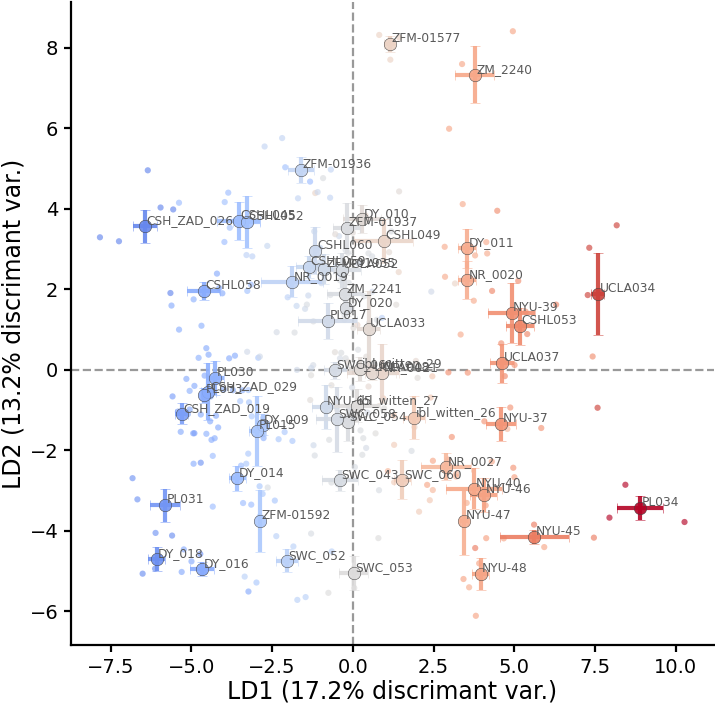

In [332]:
"""
MICE IN THE LDA SPACE -- one point per mouse, coloured by its LD1 position.
Colour, panel size, type and export all come from paper_style, so this figure
matches every other LD1 figure in the paper. ps.use('paper') in the header cell
re-renders it at journal size with no other edit.

Individual SESSIONS are drawn underneath as small dots in their mouse's colour
(SHOW_SESSIONS), so the spread the error bars summarise is visible directly.
Axis labels carry each axis's share of the between-mouse variance, taken from
`lda.explained_variance_ratio_` of the embedding fit two cells up -- note that
this is the share of the DISCRIMINANT variance, not of the variance in the
original syllable features, and that near-tied leading values mean LD1/LD2 are
free to rotate within their subspace.
"""
SHOW_LABELS = True        # mouse names next to the points; crowded at 58 mice
SEM_PER_MOUSE = True     # False keeps the original fixed /sqrt(4);
                          # True uses each mouse's own session count (see below)
SHOW_SESSIONS = True      # single sessions as small dots under the mouse means

df_lda = clustered.copy()
grouped = df_lda.groupby(['mouse_name', 'mouse_number'])
mouse_means = grouped[[0, 1, 2]].mean()
if SEM_PER_MOUSE:
    # NOTE this changes the error bars: the original divides every mouse's SD by
    # sqrt(4) regardless of how many sessions it actually has (3 to 16 here).
    mouse_stds = grouped[[0, 1, 2]].std().div(np.sqrt(grouped.size()), axis=0)
else:
    mouse_stds = grouped[[0, 1, 2]].std() / np.sqrt(4)

ld1 = mouse_means[0].values
colors = ps.ld1_colors(ld1)          # coolwarm, symmetric about 0

# variance explained per discriminant, for the axis labels. getattr guard so the
# cell still runs if it is executed without the embedding cell in the namespace.
_evr = getattr(lda, 'explained_variance_ratio_', None)
def _ld_label(k):
    if _evr is None or k >= len(_evr):
        return f'LD{k + 1}'
    return f'LD{k + 1} ({100 * _evr[k]:.1f}% discrimant var.)'

fig, ax = ps.figure('single', scale=1.5)

if SHOW_SESSIONS:
    # every session in its mouse's colour -- same colour object as the mean point,
    # so the two cannot drift apart if ld1_norm changes.
    _cmap = {m[0]: c for m, c in zip(mouse_means.index, colors)}
    _sess_c = np.array([_cmap[m] for m in df_lda['mouse_name']])
    ax.scatter(df_lda[0], df_lda[1], s=20, c=_sess_c,
               alpha=0.65, linewidths=0, zorder=1)

for (mouse, cvec) in zip(mouse_means.index, colors):
    mean_vals = mouse_means.loc[mouse]
    std_vals = mouse_stds.loc[mouse]
    ax.errorbar(mean_vals[0], mean_vals[1],
                xerr=std_vals[0], yerr=std_vals[1],
                fmt='o', color=cvec, ecolor=cvec, alpha=0.9,
                markeredgecolor='0.25', markeredgewidth=0.4, zorder=2)
    if SHOW_LABELS:
        ax.text(mean_vals[0] + 0.05, mean_vals[1] + 0.05, str(mouse[0]),
                fontsize=plt.rcParams['font.size'] * 0.55, color='0.35', zorder=3)

ax.axvline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
ax.axhline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
# SQUARE PLOTTING AREA, not a square figure: set_box_aspect fixes the ratio of the
# AXES rectangle itself, so the colorbar and labels take their space outside it and
# the data area stays square whatever the figure size or mode.
ax.set_box_aspect(1)
# If instead you want one LD unit to be the same length on both axes -- which is the
# honest choice when distances in LDA space are being read -- use equal DATA aspect
# and symmetric limits; the box then comes out square as a consequence:
#     lim = np.nanmax(np.abs(np.r_[ax.get_xlim(), ax.get_ylim()]))
#     ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')

# ps.ld1_colorbar(ax, label='LD1', values=ld1, fraction=0.046, pad=0.02)
ax.set_xlabel(_ld_label(0))
ax.set_ylabel(_ld_label(1))
fig.tight_layout()
ps.savefig(fig, 'lda12_mice', svg=True)   # PNG + vector master
plt.show()


### The same mice in 3D (LD1 x LD2 x LD3)

The leading discriminants are near-tied in `explained_variance_ratio_`, so they rotate freely among themselves and the LD1/LD2 view above is one slice through a subspace rather than *the* picture. These are static panels of the same cloud seen from a few angles: a separation that only appears at one viewpoint is a property of the projection, not of the mice.

wrote figures/lda123_mice_3d_poster_18-09-2026.png, figures/lda123_mice_3d_poster_18-09-2026.svg


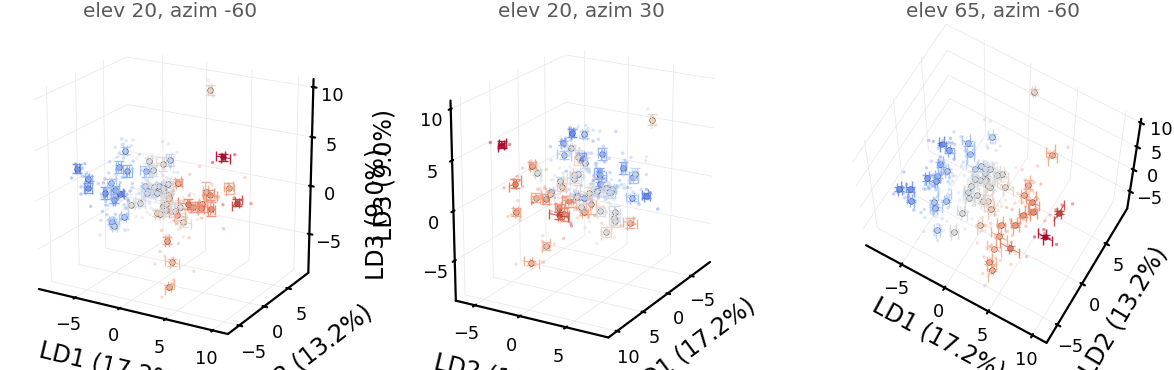

In [333]:
"""
MICE IN THE LDA SPACE, IN 3D -- LD1 x LD2 x LD3. STATIC matplotlib panels.

Same content as the LD1/LD2 figure above (one point per mouse, sessions
underneath, coloured by LD1), with the third discriminant as the depth axis.
Plain matplotlib, inline backend, no widget -- it renders as an image and
exports through ps.savefig like every other figure in the paper.

WHY SEVERAL VIEWPOINTS. The embedding cell prints `explained_variance_ratio_`
and its leading values are near-tied, which means LD1/LD2/LD3 are free to
ROTATE AMONG THEMSELVES -- no single one of them is a privileged direction, and
any ONE projection can make mice look separated (or overlapping) by accident of
the angle. Rotating is the natural way to check that; with a static figure the
substitute is to draw the same cloud from a few angles and only believe the
separations that hold up in all of them. VIEWS sets the angles.

To turn it by hand instead, set VIEWS to a single (elev, azim) pair and edit
the numbers -- elev is degrees above the LD1/LD2 plane, azim is rotation about
the vertical (LD3) axis.
"""

# (elev, azim) per panel. One entry -> a single large panel.
VIEWS_3D = [(20, -60), (20, 30), (65, -60)]
SHOW_SESSIONS_3D = True    # single sessions as small dots under the mouse means
SHOW_LABELS_3D = False     # mouse names as text; unreadable at 58 mice in 3D
SHOW_ERRORBARS_3D = True   # SEM bars per mouse (same definition as the 2D cell)
PANEL_IN_3D = 4.2          # inches per panel

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

df_lda3 = clustered.copy()
_g3 = df_lda3.groupby(['mouse_name', 'mouse_number'])
mouse_means3 = _g3[[0, 1, 2]].mean()
# per-mouse SEM using each mouse's own session count (SEM_PER_MOUSE=True in the 2D cell).
# fillna(0) because a mouse with a single session has no SD -- it gets no bar rather
# than vanishing from the figure.
mouse_sems3 = _g3[[0, 1, 2]].std().div(np.sqrt(_g3.size()), axis=0).fillna(0.0)

ld1_3 = mouse_means3[0].values
colors3 = ps.ld1_colors(ld1_3)                      # coolwarm, symmetric about 0
_cmap3 = {m[0]: c for m, c in zip(mouse_means3.index, colors3)}

# axis labels carry each discriminant's share of the BETWEEN-MOUSE (discriminant)
# variance -- not of the variance in the original syllable features
_evr3 = getattr(lda, 'explained_variance_ratio_', None)
def _ld_label3(k):
    if _evr3 is None or k >= len(_evr3):
        return f'LD{k + 1}'
    return f'LD{k + 1} ({100 * _evr3[k]:.1f}%)'

_nv = len(VIEWS_3D)
fig3, axs3 = plt.subplots(1, _nv, figsize=(PANEL_IN_3D * _nv, PANEL_IN_3D * 1.05),
                          subplot_kw={'projection': '3d'}, squeeze=False)
axs3 = axs3.ravel()

for ax3, (elev, azim) in zip(axs3, VIEWS_3D):
    if SHOW_SESSIONS_3D:
        # every session in its mouse's colour -- same colour object as the mean point.
        # depthshade=False so a point's colour means its LD1 value and nothing else;
        # the default fades far points and would read as a second colour scale.
        _sc3 = np.array([_cmap3[m] for m in df_lda3['mouse_name']])
        ax3.scatter(df_lda3[0], df_lda3[1], df_lda3[2], s=6, c=_sc3,
                    alpha=0.45, linewidths=0, depthshade=False)

    for (mouse, mean_vals), (_, sem_vals), cvec in zip(
            mouse_means3.iterrows(), mouse_sems3.iterrows(), colors3):
        if SHOW_ERRORBARS_3D:
            ax3.errorbar(mean_vals[0], mean_vals[1], mean_vals[2],
                         xerr=sem_vals[0], yerr=sem_vals[1], zerr=sem_vals[2],
                         fmt='o', ms=4, color=cvec, ecolor=cvec, alpha=0.9,
                         elinewidth=0.8, markeredgecolor='0.25', markeredgewidth=0.4)
        else:
            ax3.scatter(mean_vals[0], mean_vals[1], mean_vals[2], s=28, color=cvec,
                        edgecolors='0.25', linewidths=0.4, depthshade=False)
        if SHOW_LABELS_3D:
            ax3.text(mean_vals[0], mean_vals[1], mean_vals[2], str(mouse[0]),
                     fontsize=plt.rcParams['font.size'] * 0.5, color='0.35')

    ax3.view_init(elev=elev, azim=azim)
    # labelpad is generous on purpose: 3d tick labels sit INSIDE the axis line, so a
    # small pad puts the axis name straight through them
    ax3.set_xlabel(_ld_label3(0), labelpad=6)
    ax3.set_ylabel(_ld_label3(1), labelpad=6)
    ax3.zaxis.set_rotate_label(False)   # keep it upright, not tilted with the pane
    ax3.set_zlabel(_ld_label3(2), labelpad=14, rotation=90)
    ax3.tick_params(pad=1, labelsize=plt.rcParams['font.size'] * 0.8)
    # EQUAL DATA ASPECT: one LD unit is the same length on all three axes, so the
    # cloud is not stretched differently per axis and the panels can be compared.
    _rng3 = [np.ptp(df_lda3[k]) for k in (0, 1, 2)]
    ax3.set_box_aspect(_rng3)
    if _nv > 1:
        ax3.set_title(f'elev {elev}, azim {azim}',
                      fontsize=plt.rcParams['font.size'] * 0.9, color='0.35')
    # the 3d panes carry no information; the ticks already give the scale
    for _pane in (ax3.xaxis, ax3.yaxis, ax3.zaxis):
        _pane.pane.set_alpha(0.0)
        _pane._axinfo['grid'].update(color='0.9', linewidth=0.5)

# subplots_adjust, NOT tight_layout: tight_layout measures 2d artists and consistently
# clips the z label of a 3d axes, which is what the right-hand panel loses first
fig3.subplots_adjust(left=0.02, right=0.94, bottom=0.04, top=0.94, wspace=0.22)
ps.savefig(fig3, 'lda123_mice_3d', svg=True)   # PNG + vector master
plt.show()


### Example sessions at the extremes of the LD1/LD2/LD3 subspace

What does a mouse at one end of an individuality axis actually *do* differently? These
panels are fig 2A (syllable composition across the four trial epochs) drawn for the
sessions furthest along each of the six axis ends -- both poles of LD1, LD2 and LD3 -- so
the embedding can be read against the behaviour it came from. LD3 is included because the
leading discriminants are near-tied and rotate among themselves: the ends of LD3 are part
of the same subspace, not a separate, lesser axis.

247/263 sessions pass the missing-data screen (<= 2% of bins NaN)
skipped for missing data (would otherwise have been the extreme):
  LD1 low    CSH_ZAD_026  projection +7.83  best available 12.5% missing
  LD1 low    CSH_ZAD_026  projection +7.24  best available 10.6% missing

showing:
  LD1 low          PL031  fbd28ea6-3251-48e0-b215-2c51ec5185f7  LD1 -6.82  LD2 -2.69  LD3 +2.28  0.0% missing
  LD1 high         PL034  87ad026d-5b95-4022-8d59-c260870d830f  LD1 +10.27  LD2 -3.78  LD3 +6.94  0.0% missing
  LD2 low         NYU-48  3d59aa1a-b4ba-47fe-b9cf-741b5fdb0c7b  LD1 +3.81  LD2 -6.11  LD3 -2.95  1.5% missing
  LD2 high       ZM_2240  193fe7a8-4eb5-4f3e-815a-0c45864ddd77  LD1 +4.95  LD2 +8.42  LD3 +0.02  0.0% missing
  LD3 low         NYU-47  fc43390d-457e-463a-9fd4-b94a0a8b48f5  LD1 +3.60  LD2 -5.40  LD3 -7.85  0.0% missing
  LD3 high     ZFM-01577  09b2c4d1-058d-4c84-9fd4-97530f85baf6  LD1 +1.16  LD2 +7.71  LD3 +9.53  0.0% missing
wrote figures/lda123_extremes_map_poster_18-09-2026

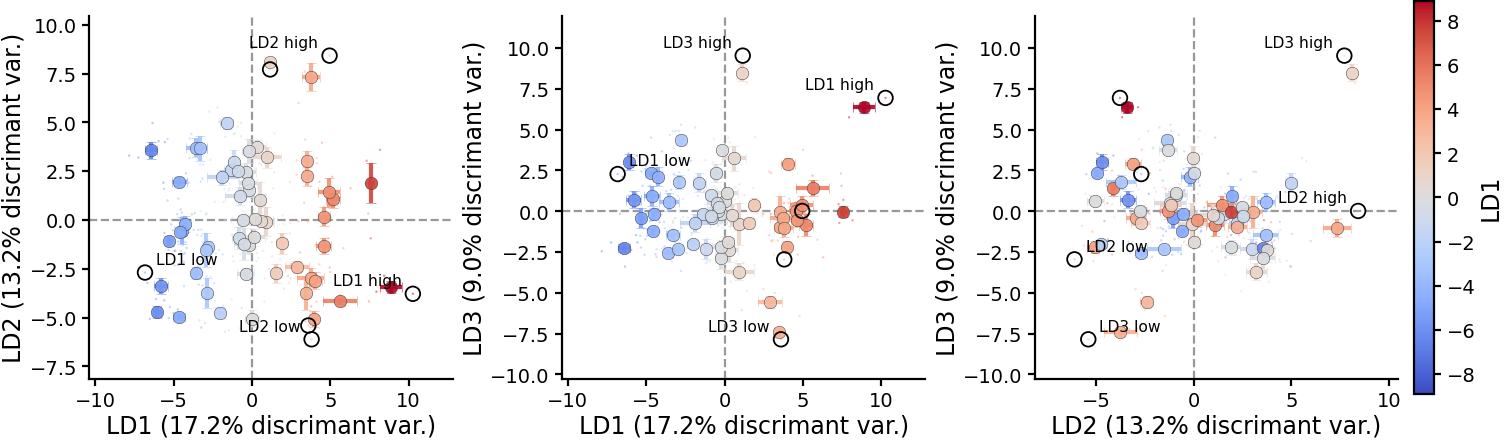

wrote figures/lda123_extremes_syllables_poster_18-09-2026.png, figures/lda123_extremes_syllables_poster_18-09-2026.svg


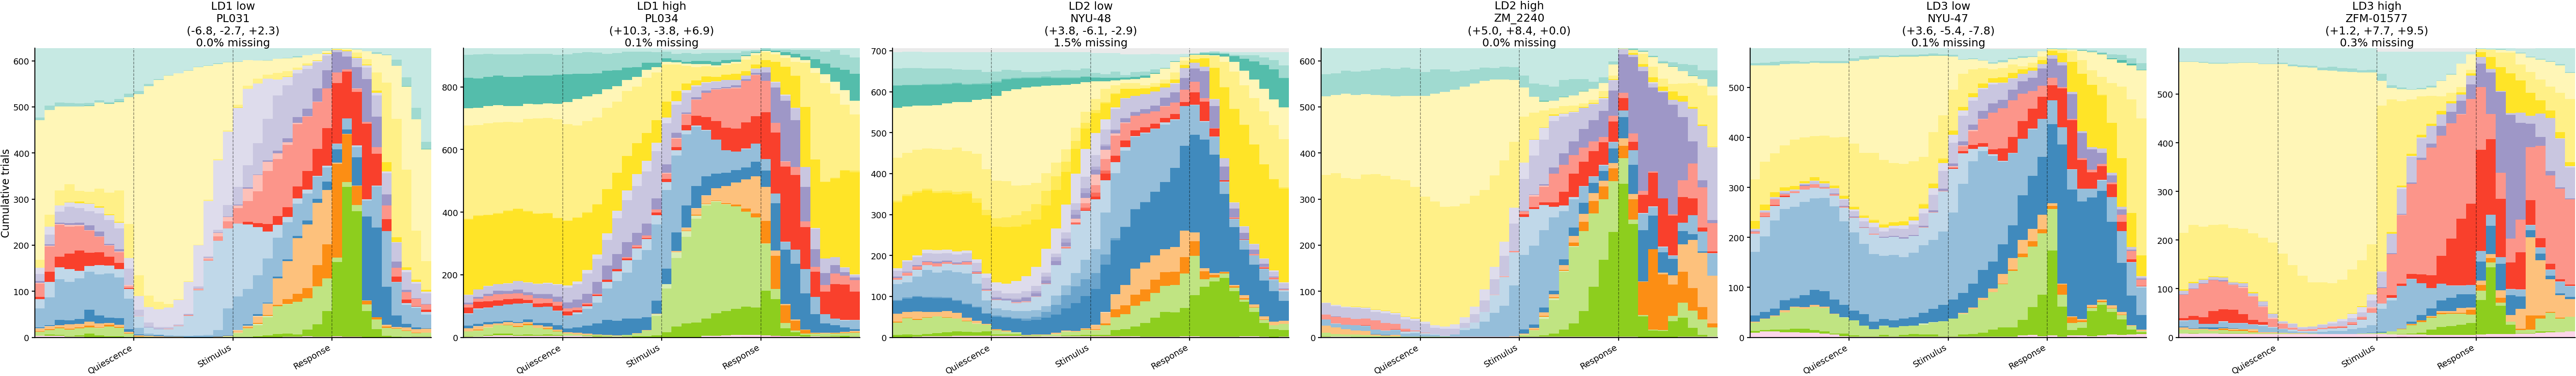

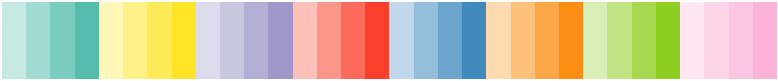

In [334]:
"""
SYLLABLE PANELS FOR THE SESSIONS AT THE EXTREMES OF THE LD1/LD2/LD3 SUBSPACE
===========================================================================
The panel is fig 2A and is drawn by paper-individuality/syllable_panels.py, the same
module 2_pre-trial/fig2.ipynb now calls -- same palette, same syllable ordering, same
sort mode, so these panels and fig 2A can be put side by side.

WHICH SESSIONS. For each direction the session furthest along it is taken. Three knobs:

  EXTREME_BY 'session' -- the single most extreme SESSION. What "extreme point in the
                 2D plot" literally means, but a lone session can be extreme because of
                 a bad camera day rather than because of the mouse, and one session is
                 not evidence about an animal.
             'mouse'  -- the most extreme MOUSE (by the mean of its sessions), then that
                 mouse's most TYPICAL session (closest to its own mean). Slower to reach
                 the edge of the cloud, but what it shows is reproducible within the
                 animal. Prefer this one for anything that goes in the paper.

  MAX_MISSING  skip sessions whose sequences are more than this fraction NaN. NOT
               cosmetic: the mouse at the LD1-low pole (CSH_ZAD_026) is missing 10-21%
               of its bins -- almost all of it a hole in the middle of the ITI, where
               40% of its bins are gone -- and the worst-tracked mouse in the file
               (NYU-30, 32-54% missing, flagged 'need to revise' in the QC sheet, which
               QC_STRICTNESS='filtered_out' does NOT drop) sits near the other end of
               LD1. A panel that is a fifth empty cannot be read as behaviour. None
               shows the literal extremes regardless.

               THE SCREEN CHANGES WHAT IS DRAWN, NEVER THE EMBEDDING. A mouse is still
               ranked on all of its sessions; only the session shown for it has to pass.
               If none of its sessions pass, the next mouse along that direction is used
               and the skip is printed, so the figure never quietly claims that a
               well-tracked mouse is the extreme one. (Dropping the badly-tracked mice
               from the LDA itself is a separate question: recomputing the embedding
               from complete trials only leaves LD1 essentially unchanged, |r| = 0.99,
               so the missing data is a problem for READING these panels, not evidence
               that the axis is an artifact.)

  DIRECTIONS   the SIX axis ends -- both poles of LD1, LD2 and LD3. The vectors are 3d
               and normalised, so a corner like 'LD1+LD3': (1, 0, 1) works as well.

               WHY LD3 IS IN HERE. The embedding's leading eigenvalues are near-tied
               (the 3d figure above says so), which means LD1/LD2/LD3 are free to rotate
               among themselves: no one of them is a privileged direction, and the
               behaviour at the ends of LD3 belongs to the individuality subspace exactly
               as LD1's does. Showing only LD1/LD2 shows two thirds of the picture. This
               is NOT a claim that LD3 means something on its own -- read the six panels
               as six points on the edge of one cloud, not as three separate axes.
"""
import importlib
import re
import syllable_panels as sp
importlib.reload(sp)          # kernels cache modules; see the paper_style note in cell 0

EXTREME_BY = 'session'        # 'mouse' (recommended) or 'session'
MAX_MISSING = 0.02            # None = no screen; 0.05 = at most 5% of bins missing
SORT_MODE_EX = 'within_bin'   # as in fig 2A: 'within_bin' or 'none' (true raster)
DIRECTIONS = {'LD1 low': (-1, 0, 0), 'LD1 high': (1, 0, 0),
              'LD2 low': (0, -1, 0), 'LD2 high': (0, 1, 0),
              'LD3 low': (0, 0, -1), 'LD3 high': (0, 0, 1)}
MAP_PLANES = [(0, 1), (0, 2), (1, 2)]   # which LD pairs the map draws

# --- the sequences, from the SAME file the design matrix was built from -----------
# build_design_matrix loads and then discards them, so they are read again here. The
# session column is derived exactly as it is there (`sample` starts with the 36-char eid),
# which is what makes these ids comparable with clustered['session'].
_seq = pd.read_parquet(data_files['syllables'])
_seq['session'] = _seq['sample'].str[:36]

# --- which sessions are well enough tracked to be shown? --------------------------
# One pass over the sequences for every session at once; missing_fraction() per candidate
# would build an image apiece for a number that needs no image.
_miss = sp.session_missing_fractions(_seq)
_miss_of = clustered['session'].map(_miss)          # aligned to clustered's rows
_ok = (_miss_of.notna() & (_miss_of <= MAX_MISSING)) if MAX_MISSING is not None \
      else pd.Series(True, index=clustered.index)
print(f'{int(_ok.sum())}/{len(_ok)} sessions pass the missing-data screen '
      + ('(none applied)' if MAX_MISSING is None else f'(<= {MAX_MISSING:.0%} of bins NaN)'))

# --- pick -------------------------------------------------------------------------
# the picking is done in the FULL 3d subspace now: a direction vector has three
# components and `proj` is the projection onto it, so 'LD3 high' is found the same way
# 'LD1 high' always was
N_LD = 3
pts = clustered[list(range(N_LD))].to_numpy(float)
mouse_of = clustered['mouse_name'].to_numpy()
ok = _ok.to_numpy()
picks, skipped = {}, []
for _name, _d in DIRECTIONS.items():
    u = np.asarray(_d, float)
    u = u / np.linalg.norm(u)
    proj = pts @ u
    if EXTREME_BY == 'mouse':
        _order = pd.Series(proj).groupby(mouse_of).mean().sort_values(ascending=False)
        for _m in _order.index:
            _sub = np.where(mouse_of == _m)[0]
            _drawable = [i for i in _sub if ok[i]]
            if not _drawable:
                skipped.append((_name, _m, float(_order[_m]),
                                float(np.nanmin(_miss_of.iloc[_sub]))))
                continue
            _cen = pts[_sub].mean(axis=0)      # the mouse's own centre, from ALL sessions
            picks[_name] = int(min(_drawable, key=lambda j: ((pts[j] - _cen) ** 2).sum()))
            break
    else:
        for i in np.argsort(-proj):
            if ok[i]:
                picks[_name] = int(i)
                break
            skipped.append((_name, mouse_of[i], float(proj[i]), float(_miss_of.iloc[i])))
    assert _name in picks, f'nothing passes the screen along {_name} -- raise MAX_MISSING'

if skipped:
    print('skipped for missing data (would otherwise have been the extreme):')
    for _n, _m, _p, _f in skipped[:12]:
        print(f'  {_n:9s} {_m:>12s}  projection {_p:+.2f}  best available {_f:.1%} missing')

sessions_ex = [clustered['session'].iloc[i] for i in picks.values()]
titles_ex = [f"{k}\n{mouse_of[i]}\n(" + ', '.join(f'{pts[i, k_]:+.1f}' for k_ in range(N_LD)) + ")"
             for k, i in picks.items()]
print('\nshowing:')
for k, i in picks.items():
    _coords = '  '.join(f'LD{k_ + 1} {pts[i, k_]:+.2f}' for k_ in range(N_LD))
    print(f"  {k:9s} {mouse_of[i]:>12s}  {clustered['session'].iloc[i]}  "
          f"{_coords}  {_miss_of.iloc[i]:.1%} missing")
if len(set(sessions_ex)) < len(sessions_ex):
    print('NOTE: the same session is extreme in more than one direction; panels repeat')
_absent = [s for s in sessions_ex if s not in set(_seq['session'])]
assert not _absent, f'no sequences for {_absent} -- design matrix and sequence file disagree'

# --- where they sit ----------------------------------------------------------------
# DRAWN EXACTLY LIKE THE LD1/LD2 FIGURE ABOVE -- same mouse means, same per-mouse SEM
# error bars, same LD1 colouring, same session dots -- so that this reads as that figure
# with four points ringed, not as a second, differently-computed embedding. The only
# additions are the rings and their labels; mouse names are left off because the four
# labels have to stay legible.
_grouped = clustered.groupby(['mouse_name', 'mouse_number'])
_mm = _grouped[[0, 1, 2]].mean()
_ms = _grouped[[0, 1, 2]].std().div(np.sqrt(_grouped.size()), axis=0)
_colors = ps.ld1_colors(_mm[0].values)
_cmap_by_mouse = {m[0]: c for m, c in zip(_mm.index, _colors)}

# ONE PANEL PER LD PAIR rather than one 3d panel: the rings have to be locatable, and
# in a 3d projection a ringed point sits at an ambiguous depth -- you cannot tell from the
# page whether it is at the near or far edge. The three planes together carry the same
# information with no depth to guess at, and an LD3 extreme is unmistakable because it
# sits at the edge of the two panels that have LD3 in them and in the middle of the third.
_lbl = globals().get('_ld_label', lambda k: f'LD{k + 1}')
_sess_c = np.array([_cmap_by_mouse[m] for m in clustered['mouse_name']])
# constrained layout, not tight_layout: the row carries one colorbar spanning all three
# panels, and tight_layout packs that on top of the right-hand panel's points
fig, axs = ps.figure('single', ncols=len(MAP_PLANES), scale=1.15, squeeze=False,
                     layout='constrained')
axs = axs[0]
_w, _h = fig.get_size_inches()
fig.set_size_inches(_w * len(MAP_PLANES) / 1.6, _h)

for ax, (_a, _b) in zip(axs, MAP_PLANES):
    ax.scatter(clustered[_a], clustered[_b], s=3, alpha=0.45, linewidths=0, zorder=1,
               c=_sess_c)
    for (_mouse, _cvec) in zip(_mm.index, _colors):
        ax.errorbar(_mm.loc[_mouse][_a], _mm.loc[_mouse][_b],
                    xerr=_ms.loc[_mouse][_a], yerr=_ms.loc[_mouse][_b],
                    fmt='o', color=_cvec, ecolor=_cvec, alpha=0.9,
                    markeredgecolor='0.25', markeredgewidth=0.4, zorder=2)
    for _k, _i in picks.items():
        # the ring is drawn in every plane, so one session can be followed across panels;
        # the LABEL only goes where that direction is actually extreme, otherwise six
        # names land on top of each other in the middle of the cloud
        ax.scatter(pts[_i, _a], pts[_i, _b], s=110, facecolor='none', edgecolor='k',
                   linewidths=1.3, zorder=4)
        # which LDs a direction's NAME mentions, so the label can be put only where that
        # direction is extreme. A custom name that mentions none of them is labelled
        # everywhere rather than nowhere.
        _named = {int(d) - 1 for d in re.findall(r'LD(\d)', _k)}
        if not _named or _named & {_a, _b}:
            # the label goes towards the middle of the panel, since the point it names is
            # at the edge by construction and an outward label would be cut off
            _out = pts[_i, _a] > np.median(pts[:, _a])
            ax.annotate(_k, (pts[_i, _a], pts[_i, _b]), textcoords='offset points',
                        xytext=(-8 if _out else 8, 6), ha='right' if _out else 'left',
                        fontsize=plt.rcParams['font.size'] * 0.7, zorder=5)
    ax.axvline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
    ax.axhline(0, color='0.6', ls='--', lw=plt.rcParams['axes.linewidth'], zorder=0)
    ax.set_box_aspect(1)
    # room for the ring labels: without it a name on an extreme point -- which is by
    # definition at the edge of the cloud -- runs off the panel
    ax.margins(0.14)
    ax.set_xlabel(_lbl(_a))
    ax.set_ylabel(_lbl(_b))

# ONE colorbar for the row, taking its space from all three panels. Attached to the last
# panel alone it sits on top of that panel's points.
ps.ld1_colorbar(list(axs), label='LD1', values=_mm[0].values, fraction=0.015, pad=0.01)
ps.savefig(fig, 'lda123_extremes_map', svg=True)
plt.show()

# --- the panels --------------------------------------------------------------------
# nan_color + annotate_missing: even under the screen the panels are not equally tracked,
# and left transparent a session missing part of its ITI looks like one with fewer trials.
fig, axs, im = sp.session_panels(_seq, sessions_ex, titles=titles_ex,
                                 sort_mode=SORT_MODE_EX, scale=1.4,
                                 nan_color='0.92', annotate_missing=True)
fig.tight_layout()
ps.savefig(fig, 'lda123_extremes_syllables', svg=True)
plt.show()

# the 32-syllable key (8 paw hues x 4 whisk/lick shades), same palette as fig 2A
fig, ax = plt.subplots(figsize=(10, 1))
sp.palette_strip(ax)
plt.show()


### A wall of sessions

The extremes panel above shows four sessions chosen to make a point. This one shows a random
draw, so the eye gets the spread rather than the argument: how much of the syllable structure
is shared across the population and how much is idiosyncratic.

20 sessions drawn from 247 (17 mice), ordered by random
wrote figures/syllable_wall_random_poster_18-09-2026.png, figures/syllable_wall_random_poster_18-09-2026.svg


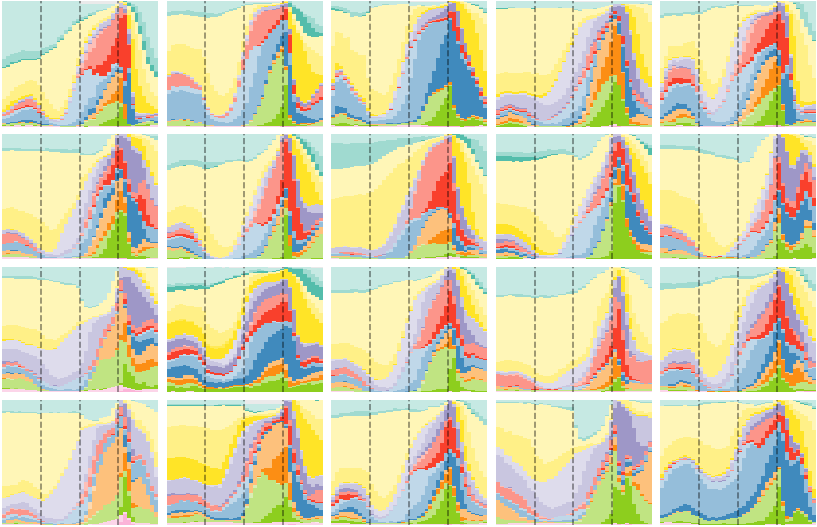

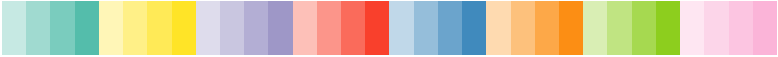

In [335]:
"""
RANDOM SESSIONS -- one small panel each, no furniture
"""
import importlib
import syllable_panels as sp
importlib.reload(sp)

N_RANDOM = 20
RANDOM_SEED = 0
GRID_COLS = 5
SORT_BY = 'random'        # 'random' keeps the draw in random order;
                          # 'ld1' orders the same draw along LD1, so the panel doubles as a
                          # gradient and you can see whether the axis corresponds to anything
                          # visible. The DRAW is random either way -- only the layout changes.
RANDOM_RESPECT_SCREEN = True   # skip sessions failing the MAX_MISSING screen used above

_seq_r = _seq if '_seq' in globals() else pd.read_parquet(data_files['syllables']).assign(
    session=lambda d: d['sample'].str[:36])

_pool = clustered.copy()
if RANDOM_RESPECT_SCREEN and MAX_MISSING is not None:
    _mf = sp.session_missing_fractions(_seq_r)
    _pool = _pool[_pool['session'].map(_mf).fillna(1) <= MAX_MISSING]
_pool = _pool[_pool['session'].isin(set(_seq_r['session']))]

_rng_r = np.random.default_rng(RANDOM_SEED)
_take = _rng_r.choice(len(_pool), min(N_RANDOM, len(_pool)), replace=False)
_draw = _pool.iloc[np.sort(_take)]
if SORT_BY == 'ld1':
    _draw = _draw.sort_values(0)
print(f'{len(_draw)} sessions drawn from {len(_pool)} '
      f'({_draw["mouse_name"].nunique()} mice), ordered by {SORT_BY}')

_ncols = GRID_COLS
_nrows = int(np.ceil(len(_draw) / _ncols))
fig, axs = plt.subplots(_nrows, _ncols, figsize=(2.1 * _ncols, 1.7 * _nrows), squeeze=False)
_cmap, _norm = sp.syllable_cmap(), sp.syllable_norm()
for ax, (_, r) in zip(axs.ravel(), _draw.iterrows()):
    sp.plot_session(ax, _seq_r, r['session'], cmap=_cmap, norm=_norm,
                    sort_mode='within_bin', nan_color='0.92')
    # strip every bit of furniture: at this size the shape is the message
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(''); ax.set_ylabel('')
    for s in ax.spines.values():
        s.set_visible(False)
for ax in axs.ravel()[len(_draw):]:
    ax.set_visible(False)
fig.subplots_adjust(wspace=0.06, hspace=0.06)
ps.savefig(fig, f'syllable_wall_{SORT_BY}', svg=True)
plt.show()

# the key, once, rather than on every panel
fig, ax = plt.subplots(figsize=(10, 0.7))
sp.palette_strip(ax)
plt.show()


In [336]:
np.sum(lda.explained_variance_ratio_)

np.float64(1.0000000000000002)

Text(0.5, 0, 'LDA components')

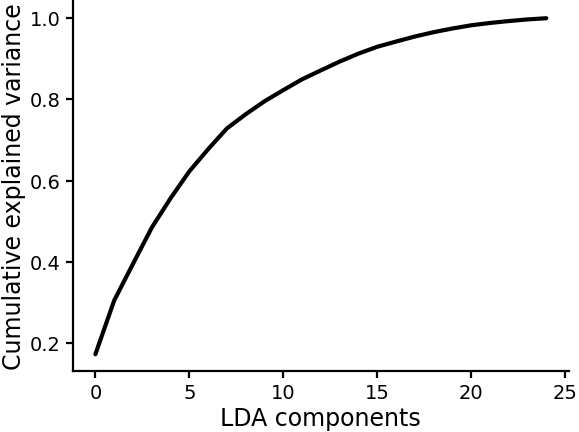

In [337]:
plt.plot(np.cumsum(lda.explained_variance_ratio_), color='black')
plt.ylabel('Cumulative explained variance')
plt.xlabel('LDA components')

# Train/ test mouse correlations

In [338]:
n_per_mouse = 3
lda_components = min_components

lda_to_check = 0

# final_matrix = np.array(norm_array)
# final_matrix = np.array(mat)
final_matrix = np.array(norm_pop)

X = final_matrix.copy()
y = pd.factorize(mouse_names)[0]

n_samples = X.shape[0]
mouse_means = np.zeros(len(y)) * np.nan
ld_held_out = np.zeros(len(y)) * np.nan

# Subsample balanced sessions for training in each fold
for test_idx in range(n_samples):
    
    X_test = X[test_idx:test_idx+1]
    y_test = y[test_idx:test_idx+1]

    train_idx = np.setdiff1d(np.arange(n_samples), test_idx)
    X_train_full = X[train_idx]
    y_train_full = y[train_idx]

    # --- balanced subsampling for training ---
    # cap = maximum contribution (header cell). The original guard was worse here:
    # with n_per_mouse=3 the 20 three-session mice have 2 left after leave-one-out,
    # below the cap, so they were dropped in EVERY fold -- mouse_means came back NaN
    # and they vanished from the LD1 analysis silently.
    balanced_idx = []
    for m in np.unique(y_train_full):
        m_idx = np.where(y_train_full == m)[0]
        take = min(n_per_mouse, len(m_idx))
        if take > 0:
            balanced_idx.extend(rng.choice(m_idx, take, replace=False))

    balanced_idx = np.array(balanced_idx)
    X_train = X_train_full[balanced_idx]
    y_train = y_train_full[balanced_idx]

    # --- true labels run ---
    lda = LinearDiscriminantAnalysis(
        priors=np.ones(len(np.unique(y_train))) / len(np.unique(y_train)),
        n_components=lda_components)
    
    lda.fit(X_train, y_train)
    transformed = lda.transform(X_train)
    mouse_means[test_idx] = np.mean(transformed[y_train == y_test, lda_to_check])  # LD1
    ld_held_out[test_idx] = lda.transform(X_test)[0][lda_to_check]  # if multiple sessions, take mean

Text(0.05, 0.95, 'r = 0.855, p = 2.28e-76')

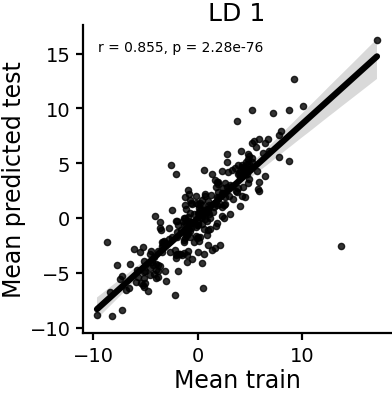

In [339]:
corr_df = pd.DataFrame(columns=['mean_train', 'transformed_test'])
corr_df['mean_train'] = mouse_means
corr_df['transformed_test'] = ld_held_out
corr_df = corr_df.dropna()

fig, ax = ps.figure('single', scale=.8)
ax.set_box_aspect(1)              # the AXES rectangle is square
sns.regplot(x=np.array(corr_df['mean_train']).astype(float), 
            y=corr_df['transformed_test'].astype(float), scatter_kws={'s': 20}, color='black', ci=95) 
plt.xlabel('Mean train')
plt.ylabel('Mean predicted test')
plt.title('LD '+str(lda_to_check+1))

res = stats.pearsonr(np.array(corr_df['mean_train']).astype(float), corr_df['transformed_test'].astype(float))
plt.text(0.05, 0.95, f'r = {res.statistic:.3f}, p = {res.pvalue:.2e}',
         transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')

# plt.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'train_test_corr.svg', format='svg', bbox_inches='tight')